# Notebook 15 - Partial Differential Equations

Partial differential equations describe some of the most important phenomena in nature (waves, heat transfer, electrostatics, fluid dynamics, gravitation, quantum mechanics, diffusion). They are also very hard to solve! Luckily we have numerical methods which can be used to approximate the solution.

#### Examples:

Laplace's equation for the electric potential:

$\frac{\partial^2 \phi}{\partial x^2}+\frac{\partial^2 \phi}{\partial y^2}+\frac{\partial^2 \phi}{\partial z^2} = 0$

Poisson's equation for the electric potential:

$\frac{\partial^2 \phi}{\partial x^2}+\frac{\partial^2 \phi}{\partial y^2}+\frac{\partial^2 \phi}{\partial z^2} = -\frac{\rho}{\epsilon}$

Poisson's equation for gravity:

$\frac{\partial^2 \phi}{\partial x^2}+\frac{\partial^2 \phi}{\partial y^2}+\frac{\partial^2 \phi}{\partial z^2} = 4\pi G\rho$

Wave equation (1D):

$\frac{\partial^2 \psi}{\partial t^2}=c^2 \frac{\partial^2 \psi}{\partial x^2}$

Heat equation (alpha is the "diffusivity"):

$\frac{\partial T}{\partial t}=\alpha \Big(\frac{\partial^2 T}{\partial x^2}+\frac{\partial^2 T}{\partial y^2}+\frac{\partial^2 T}{\partial z^2}\Big)$


Schrodinger equation:

$i\hbar\frac{\partial}{\partial t}\Psi(\vec{r},t)=\Big[\frac{-\hbar^2}{2m}\Big(\frac{\partial^2 }{\partial x^2}+\frac{\partial^2 }{\partial y^2}+\frac{\partial^2 }{\partial z^2}\Big)+V(\vec{r},t)\Big]\Psi(\vec{r},t)$




# Boundary value problems

### Solving Laplace's Equation

Example from book: An empty box has conducting walls. The top wall is at a voltage V, and all of the other walls have a voltage of 0 (they are grounded). What is the value of the electric potential at some location within the box?

Goal: Solve Laplace's equation

$\frac{\partial^2 \phi}{\partial x^2}+\frac{\partial^2 \phi}{\partial y^2}+\frac{\partial^2 \phi}{\partial z^2} = 0$

with the given boundary conditions.

We can solve such "boundary value problems" by using the method of finite differences in combination with the relaxation method. We will split the box up into a grid and solve Laplace's equation at each grid point.

Chalk board: Show that on a grid with spacing $a$, solving  Laplace's equation becomes solving the following equation for each grid point:

$\phi(x+a,y)+\phi(x-a,y)+\phi(x,y+a)+\phi(x,y-a)-4\phi(x,y)=0$

or rearranging:

$\phi(x,y)=\frac{1}{4}[\phi(x+a,y)+\phi(x-a,y)+\phi(x,y+a)+\phi(x,y-a)]$

We have a linear set of simultaneous equations for each grid point and we can use the relaxation method to solve.

Solving PDEs with the method of finite differences in combination with the relaxation method is known as the "Jacobi method". The relaxation method fails for some systems of equations but it always works for PDEs. The only problem is that the Jacobi method is slow. Solving for a 100x100 grid requires solving 10,000 simultaneous equations.

#### Boundary conditions: Square box with top edge at voltage = 1 V and all other edges at 0 V

In [2]:
from numpy import empty,zeros,max

# Constants
M = 100         # Grid squares on a side
V = 1.0         # Voltage at top wall
target = 1e-4   #1e-6   # Target accuracy

# Create arrays to hold potential values
phi = zeros([M+1,M+1],float) # this will be used to store the current grid
phi[0,:] = V # Set boundary conditions
phiprime = empty([M+1,M+1],float) # This will be used to store the old grid
#tempx = zeros([M+1,M+1],float)

print("Phi before loop:")
print(phi)

# Main loop - Relaxation Method for PDE
delta = 1.0
while delta>target:

    phiprime[:,:] = phi[:,:]  # Copy all values from phi to phiprime

    # Calculate new values of the potential
    for i in range(M+1):
        for j in range(M+1):

            # On the boundaries the voltage must = boundary conditions
            if i==0 or i==M or j==0 or j==M:
                phiprime[i,j] = phi[i,j]
            # In the middle grid estimate voltage based on neighboring voltages
            else:
                phiprime[i,j] = (phi[i+1,j] + phi[i-1,j] \
                                 + phi[i,j+1] + phi[i,j-1])/4

    # Calculate maximum difference from old values
    delta = max(abs(phi-phiprime))

    # Swap the two arrays around
    phi,phiprime = phiprime,phi

print("Phi after loop:")
print(phi)


Phi before loop:
[[1. 1. 1. ... 1. 1. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Phi after loop:
[[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 1.00000000e+00
  1.00000000e+00 1.00000000e+00]
 [0.00000000e+00 4.99666100e-01 6.96985091e-01 ... 6.96985091e-01
  4.99666100e-01 0.00000000e+00]
 [0.00000000e+00 3.01679999e-01 4.98665779e-01 ... 4.98665779e-01
  3.01679999e-01 0.00000000e+00]
 ...
 [0.00000000e+00 1.55591261e-05 3.10972445e-05 ... 3.10972445e-05
  1.55591261e-05 0.00000000e+00]
 [0.00000000e+00 7.73947579e-06 1.54684860e-05 ... 1.54684860e-05
  7.73947579e-06 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]


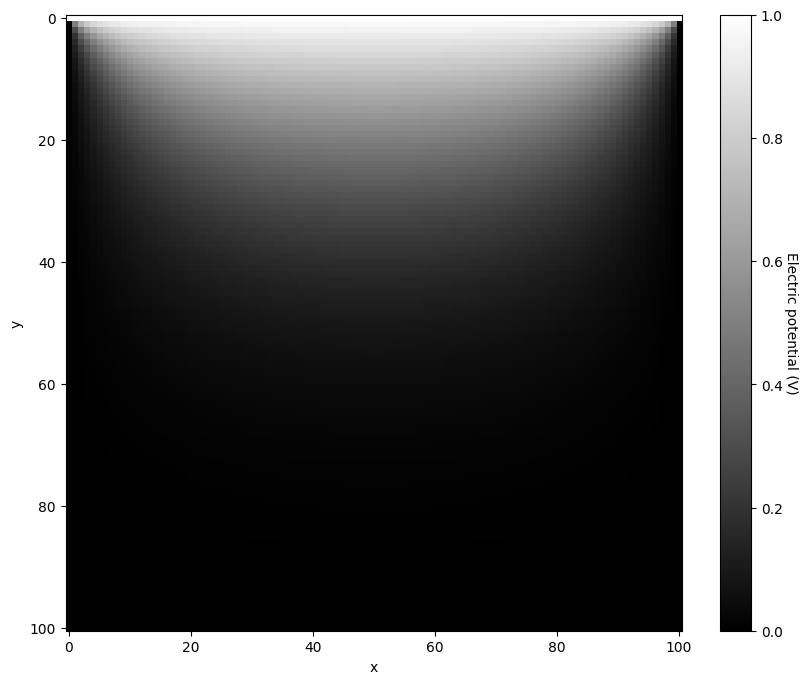

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 10, 8
plt.imshow(phi,origin='upper')
plt.gray()
plt.colorbar().set_label('Electric potential (V)', rotation=270, labelpad=11)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

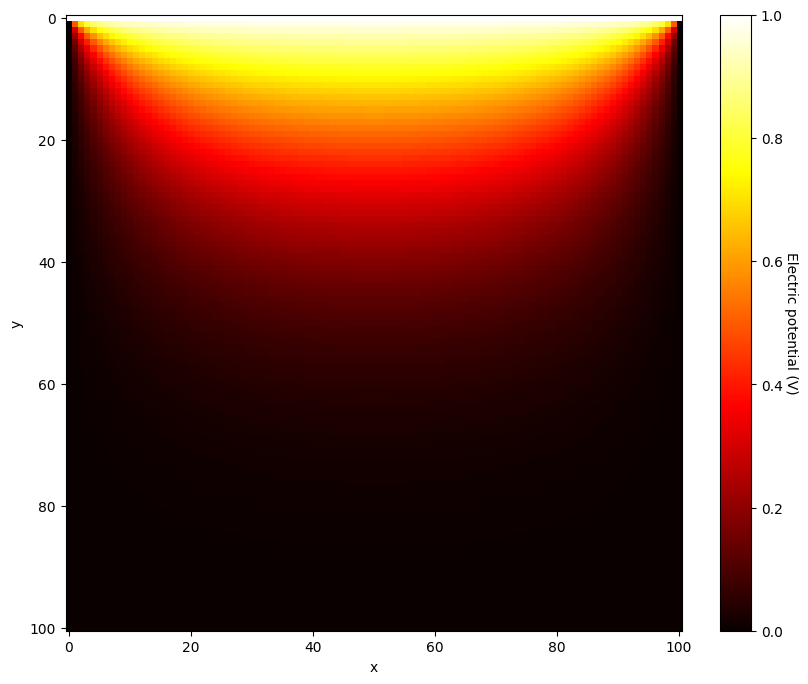

In [4]:
plt.imshow(phi, cmap="hot", origin='upper')
plt.colorbar().set_label('Electric potential (V)', rotation=270, labelpad=11)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

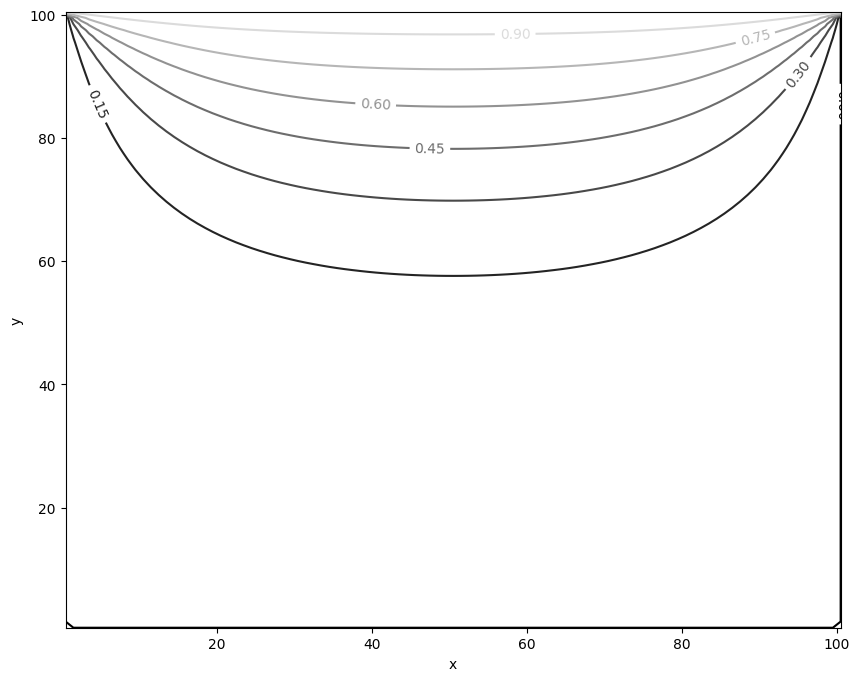

In [5]:
# Draw equipotentials with a contour plot:
#plt.contour(phi, origin='upper')
CS = plt.contour(phi, origin='image')
plt.clabel(CS, inline=1, fontsize=10)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

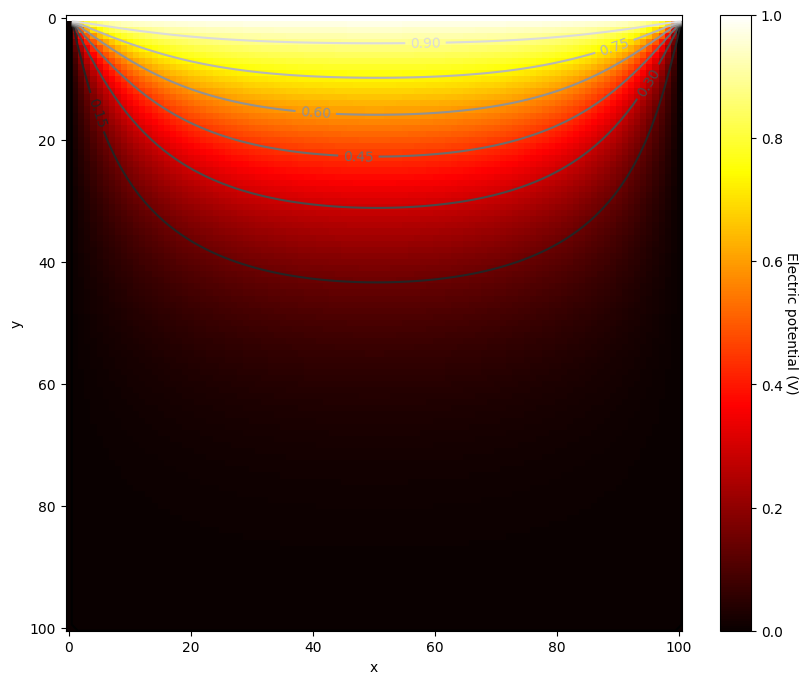

In [6]:
plt.imshow(phi, cmap="hot", origin='upper')
plt.colorbar().set_label('Electric potential (V)', rotation=270, labelpad=11)
CS = plt.contour(phi, origin='lower')
plt.clabel(CS, inline=1, fontsize=10)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

#### Boundary conditions: Square box with top edge at voltage = 1 V, bottom edge at voltage = -1 V, right edge at 2V, and all other edges at 0 V

In [7]:
from numpy import empty,zeros,max

plt.rcParams['figure.figsize'] = 10, 8

# Constants
M = 100         # Grid squares on a side
V = 1.0         # Voltage at top wall
target = 1e-4#1e-6   # Target accuracy

# Create arrays to hold potential values
phi2 = zeros([M+1,M+1],float)
phi2[0,:] = V
phi2[:,0] = 2*V
phi2[M,:] = -V
phiprime = empty([M+1,M+1],float)

# Main loop
delta = 1.0
while delta>target:

    phiprime[:,:] = phi2[:,:]  # Copy all values from phi to phiprime

    # Calculate new values of the potential
    for i in range(M+1):
        for j in range(M+1):
            if i==0 or i==M or j==0 or j==M:
                phiprime[i,j] = phi2[i,j]
            else:
                phiprime[i,j] = (phi2[i+1,j] + phi2[i-1,j] \
                                 + phi2[i,j+1] + phi2[i,j-1])/4

    # Calculate maximum difference from old values
    delta = max(abs(phi2-phiprime))

    # Swap the two arrays around
    phi2,phiprime = phiprime,phi2


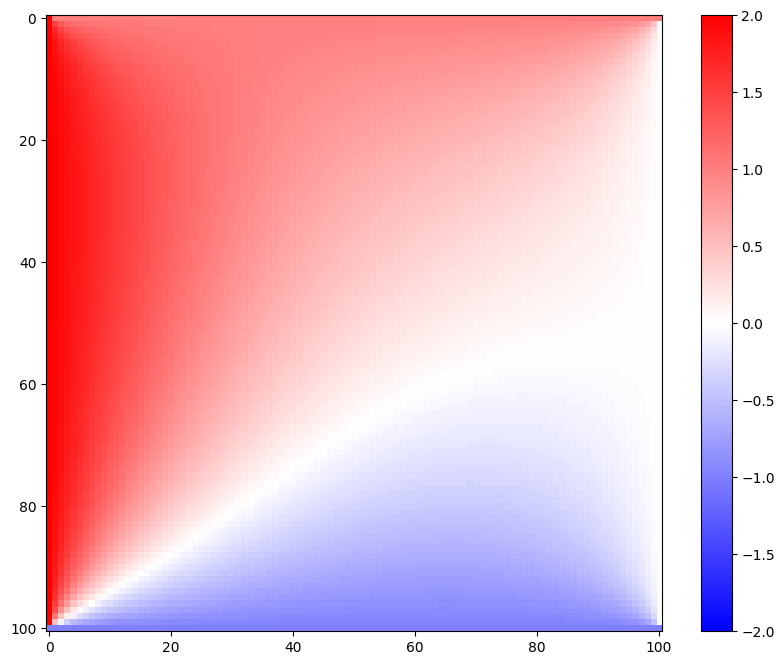

In [8]:
import pylab as plt

plt.imshow(phi2, cmap="bwr", origin="upper")
plt.clim(-2,2)
plt.colorbar()
plt.show()

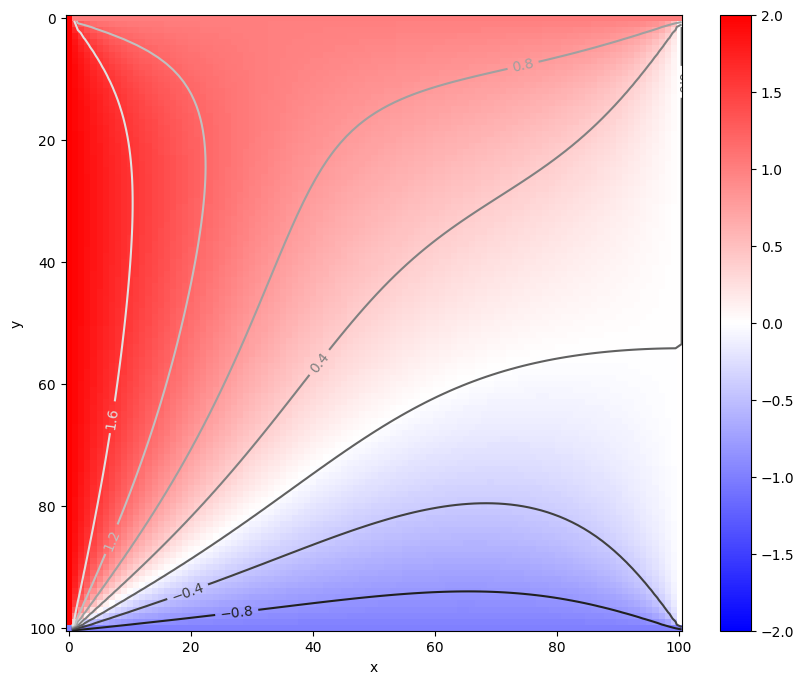

In [9]:
plt.imshow(phi2, cmap="bwr", origin="upper")
plt.clim(-2,2)
plt.colorbar()
CS = plt.contour(phi2, origin='lower')
plt.clabel(CS, inline=1, fontsize=10) #, origin='upper'
plt.xlabel("x")
plt.ylabel("y")
plt.show()

#### Boundary conditions: Square box with top and bottom edge at voltage = - 1 V, and side edges at voltage = 2V

In [10]:

from numpy import empty,zeros,max

plt.rcParams['figure.figsize'] = 10, 8

# Constants
M = 100         # Grid squares on a side
V = 1.0         # Voltage at top wall
target = 1e-4#1e-6   # Target accuracy

# Create arrays to hold potential values
phi3 = zeros([M+1,M+1],float)
phi3[0,:] = -V
phi3[:,0] = 2*V
phi3[M,:] = -V
phi3[:,M] = 2*V
phiprime = empty([M+1,M+1],float)

# Main loop
delta = 1.0
while delta>target:

    phiprime[:,:] = phi3[:,:]  # Copy all values from phi to phiprime

    # Calculate new values of the potential
    for i in range(M+1):
        for j in range(M+1):
            if i==0 or i==M or j==0 or j==M:
                phiprime[i,j] = phi3[i,j]
            else:
                phiprime[i,j] = (phi3[i+1,j] + phi3[i-1,j] \
                                 + phi3[i,j+1] + phi3[i,j-1])/4

    # Calculate maximum difference from old values
    delta = max(abs(phi3-phiprime))

    # Swap the two arrays around
    phi3,phiprime = phiprime,phi3

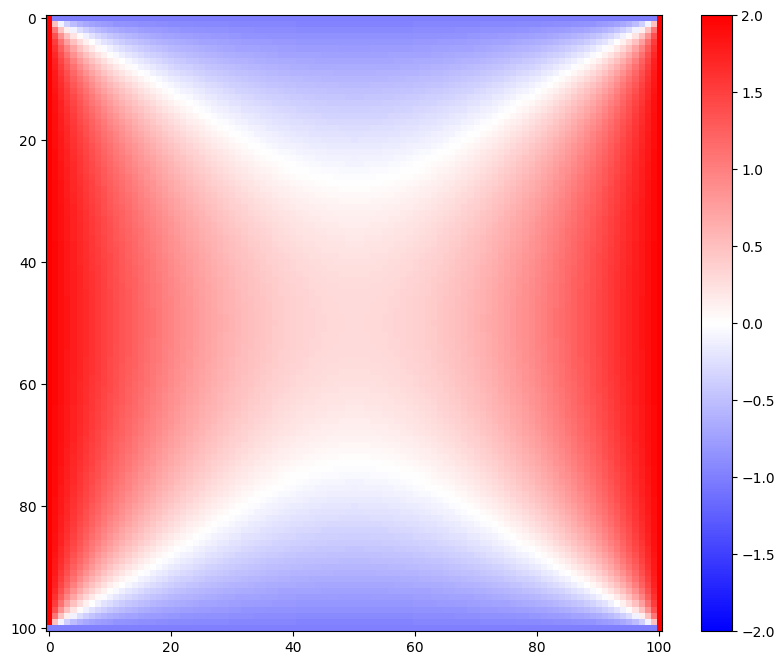

In [11]:
import pylab as plt

plt.imshow(phi3, cmap="bwr", origin="upper")
plt.clim(-2,2)
plt.colorbar()
plt.show()


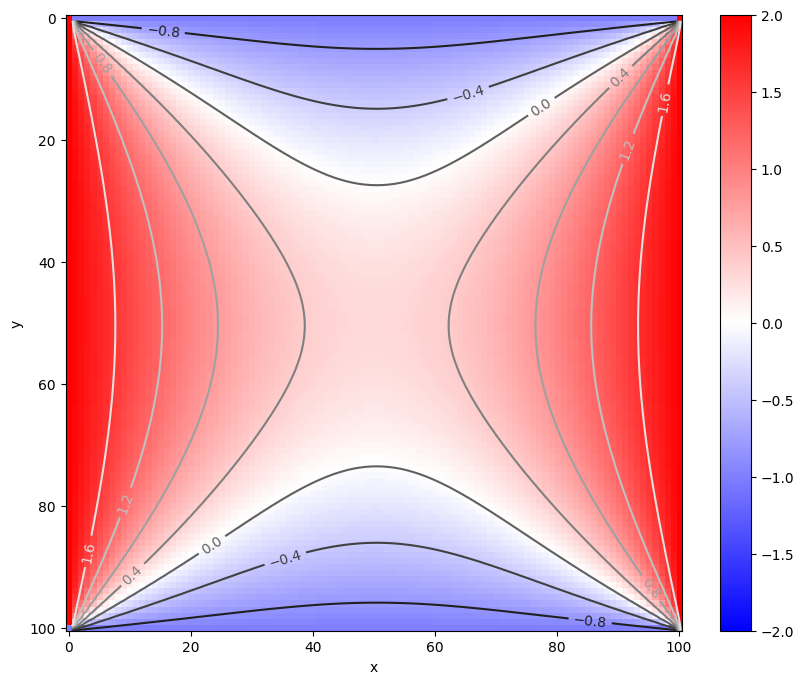

In [12]:

plt.imshow(phi3, cmap="bwr", origin="upper")
plt.clim(-2,2)
plt.colorbar()

CS = plt.contour(phi3, origin='lower')
plt.clabel(CS, inline=1, fontsize=10)#, origin='upper'
plt.xlabel("x")
plt.ylabel("y")
plt.show()



Let's try adding a grounded plate within the box:

In [13]:
from numpy import empty,zeros,max

plt.rcParams['figure.figsize'] = 10, 8

# Constants
M = 100         # Grid squares on a side
V = 1.0         # Voltage at top wall
target = 1e-4#1e-6   # Target accuracy

# Create arrays to hold potential values
phi4 = zeros([M+1,M+1],float)

# Boundary contitions - make two edges V and other two 0
phi4[0,:] = V
phi4[:,0] = V
phi4[M,:] = 0
phi4[:,M] = 0

# Add a grounded plate using slicing
phi4[10,30:70] = 0


phiprime = empty([M+1,M+1],float)

# Main loop
delta = 1.0
while delta>target:

    phiprime[:,:] = phi4[:,:]  # Copy all values from phi to phiprime

    # Calculate new values of the potential
    for i in range(M+1):
        for j in range(M+1):
            if i==0 or i==M or j==0 or j==M or (i==10 and (j<70 and j>30)):
                phiprime[i,j] = phi4[i,j]
            else:
                phiprime[i,j] = (phi4[i+1,j] + phi4[i-1,j] \
                                 + phi4[i,j+1] + phi4[i,j-1])/4

    # Calculate maximum difference from old values
    delta = max(abs(phi4-phiprime))

    # Swap the two arrays around
    phi4,phiprime = phiprime,phi4

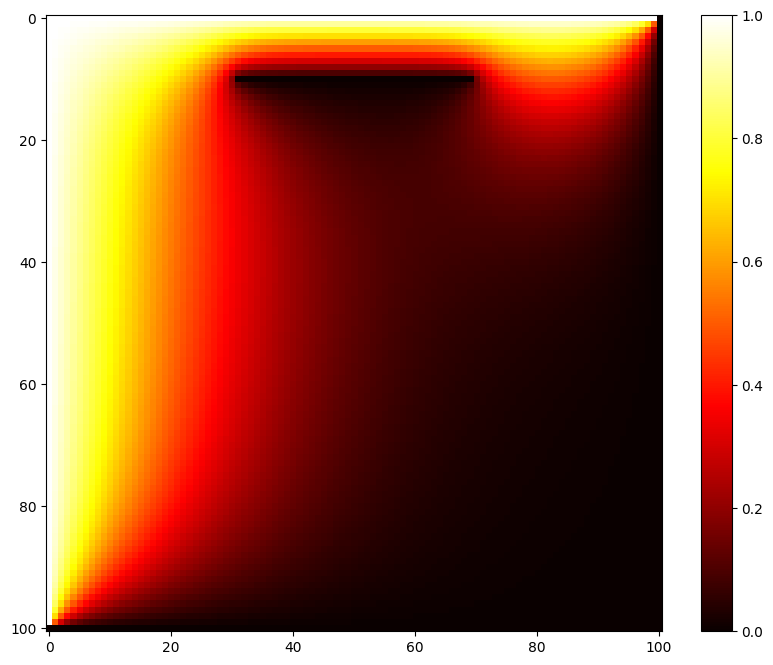

In [14]:
import pylab as plt

plt.imshow(phi4, cmap="hot", origin="upper")
#plt.clim(-2,2)
plt.colorbar()
plt.show()

# Poisson's Equation

Poisson's equation for the electric potential:

$\frac{\partial^2 \phi}{\partial x^2}+\frac{\partial^2 \phi}{\partial y^2}+\frac{\partial^2 \phi}{\partial z^2} = -\frac{\rho}{\epsilon}$



While Laplace's equation ($\nabla^2 \phi = 0$) involved every location wanting to be the average of their neighbors, Poisson's equation adds a source, and therefore there is another influcence on the potential at the grid points where there is a source.  


With the method of finite differences this becomes:

$\phi(x,y)=\frac{1}{4}[\phi(x+a,y)+\phi(x-a,y)+\phi(x,y+a)+\phi(x,y-a)]+\frac{a^2}{4\epsilon_0}\rho(x,y)$

Now the value of the potential at one location is the average of their neighbors plus the source.

  * If $\rho$ is positive, you are forced to be higher than the average.
  * If $\rho$ is negative, you are forced to be lower than the average.
  * If $\rho$ is zero, you simply become the average (this is Laplace's equation).

#### Examples
Use this to find the potential at every point inside a box with two square charges inside:

In [15]:
# Exercise 9.1

import numpy as np
import time
start = time.time()

# constants
L = 1.0 # length of box
M = 100 # grid squares
a = L/M # size of a grid square

rho0 = 1.0 # Charge density
epsilon = 1.0 # Electrical permitivity

target = 1e-5   # Target accuracy

# Create arrays to hold potential values
phi_91      = np.zeros([M+1,M+1],float)
phiprime_91 = np.zeros([M+1,M+1],float)
rho_91      = np.zeros([M+1,M+1],float)
rho_91[20:41,60:81] = rho0
rho_91[60:81,20:41] = -rho0

# Main loop
delta = 1.0
count = 0
#while count<3:
while delta>target:

    # Calculate new values of the potential
    for i in range(M+1):
        for j in range(M+1):
            if i==0 or i==M or j==0 or j==M :
                phiprime_91[i,j] = phi_91[i,j]
            else:
                phiprime_91[i,j] = (phi_91[i+1,j] + phi_91[i-1,j] \
                                 + phi_91[i,j+1] + phi_91[i,j-1])/4 \
                                + rho_91[i,j]*a*a/(4*epsilon)

    # Calculate maximum difference from old values
    delta = np.max(abs(phi_91-phiprime_91))

    # Swap the two arrays around
    phi_91,phiprime_91 = phiprime_91,phi_91

    count +=1

end = time.time()
print("Time Elapsed: ",end - start)

Time Elapsed:  5.277757167816162


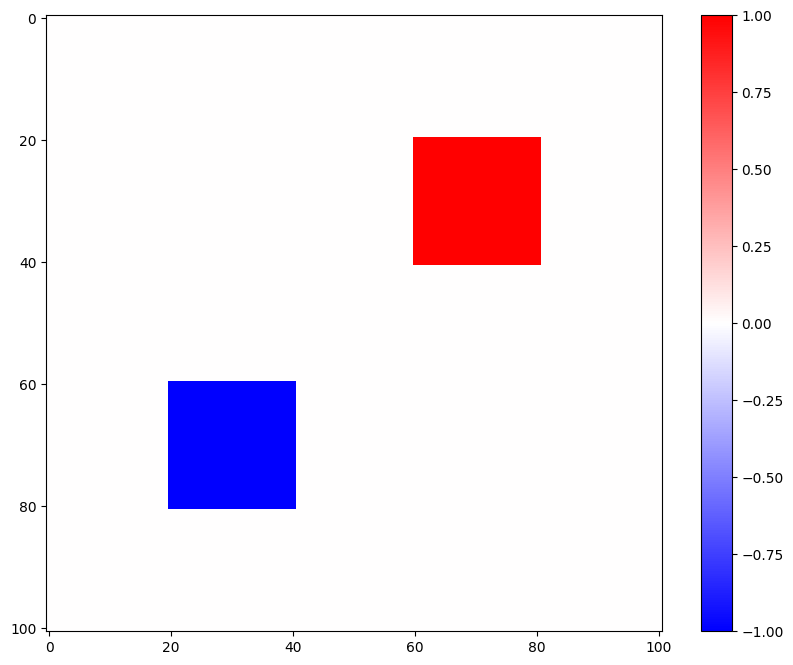

In [16]:
# Plot the charge boundaries
import pylab as plt
plt.rcParams['figure.figsize'] = 10, 8
plt.imshow(rho_91, cmap="bwr")
#plt.clim(-2,2)
plt.colorbar()
plt.show()

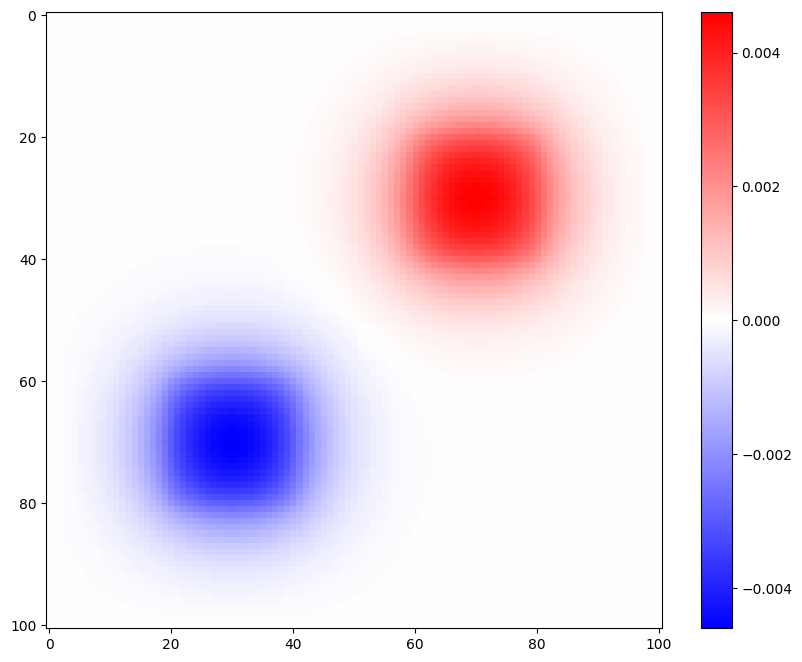

In [17]:
# Plot the potential
import pylab as plt
plt.rcParams['figure.figsize'] = 10, 8
plt.imshow(phi_91, cmap="bwr")
#plt.clim(-2,2)
plt.colorbar()
plt.show()

Let's try solving it without looping over each array element (use numpy slicing instead:)

In [18]:
import time
start = time.time()

phi_92      = np.zeros([M+1,M+1],float)
phiprime_92 = np.zeros([M+1,M+1],float)
rho_92      = np.zeros([M+1,M+1],float)
rho_92[20:41,60:81] = rho0
rho_92[60:81,20:41] = -rho0


# constants
L = 1.0 # length of box
M = 100 # grid squares
a = L/M # size of a grid square

rho0 = 1.0 # Charge density
epsilon = 1.0 # Electrical permitivity

target = 1e-5   # Target accuracy

delta = 1.0
count = 0

while delta>target:

    # Fix boundaries at 0V
    phiprime_92[0,:] = 0.0
    phiprime_92[M,:] = 0.0
    phiprime_92[:,0] = 0.0
    phiprime_92[:,M] = 0.0

    # Interior values
    phiprime_92[1:M,1:M] = (phi_92[0:M-1,1:M] + phi_92[2:M+1,1:M] \
                       + phi_92[1:M,0:M-1] + phi_92[1:M,2:M+1])/4 \
                       + rho_92[1:M,1:M]*a*a/(4*epsilon)

    # Calculate maximum difference from old values
    delta = np.max(abs(phi_92-phiprime_92))

    # Swap the two arrays around
    phi_92,phiprime_92 = phiprime_92,phi_92


end = time.time()
print("Time Elapsed: ",end - start)

Time Elapsed:  0.039644718170166016


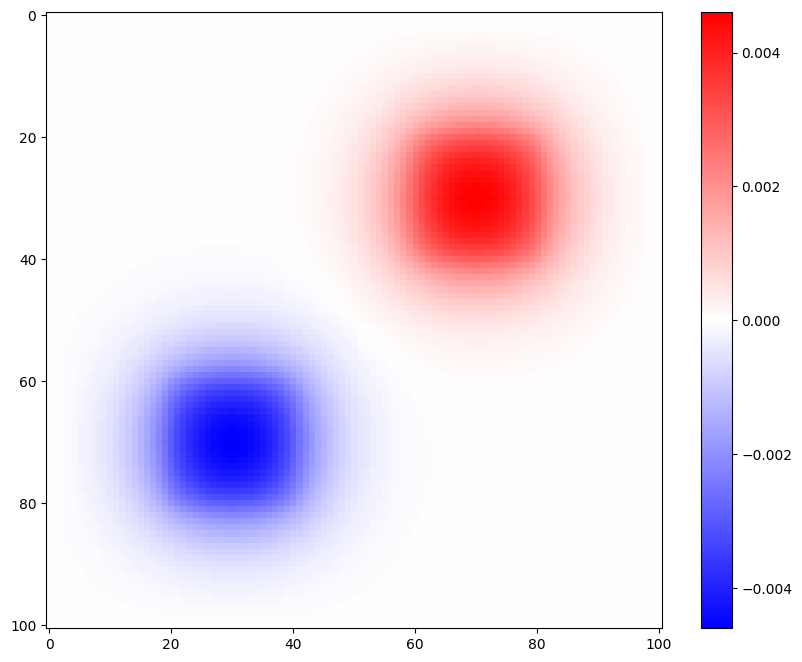

In [19]:
import pylab as plt
plt.rcParams['figure.figsize'] = 10, 8
plt.imshow(phi_92, cmap="bwr")
#plt.clim(-2,2)
plt.colorbar()
plt.show()

In [20]:
N=6
test = np.zeros([N+1,N+1],float)
test[2:5,2:5] = rho0
print(test)

[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


In [21]:
print(test[1:N,1:N] )

[[0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0.]]


In [22]:
print(test[0:N-1,1:N] )

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]]


In [23]:
print(test[2:N+1,1:N])

[[0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [24]:
print(test[1:N,0:N-1])

[[0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]


In [25]:
print(test[1:N,2:N+1])

[[0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [26]:
# Exercise 9.1 (now use numpy slice)

import numpy as np
import time
start = time.time()

# constants
L = 1.0 # length of box
M = 100 # grid squares
a = L/M # size of a grid square

rho0 = 1.0 # Charge density
epsilon = 1.0 # Electrical permitivity

target = 1e-5   # Target accuracy

# Create arrays to hold potential values
phi      = np.zeros([M+1,M+1],float)
phiprime = np.zeros([M+1,M+1],float)
rho      = np.zeros([M+1,M+1],float)
rho[20:41,60:81] = rho0
rho[60:81,20:41] = -rho0

# Main loop
delta = 1.0

while delta>target:

    # Fix boundaries at 0V
    phiprime[0,:] = 0.0
    phiprime[M,:] = 0.0
    phiprime[:,0] = 0.0
    phiprime[:,M] = 0.0

    # Interior values
    phiprime[1:M,1:M] = (phi[0:M-1,1:M] + phi[2:M+1,1:M] \
                       + phi[1:M,0:M-1] + phi[1:M,2:M+1])/4 \
                       + rho[1:M,1:M]*a*a/(4*epsilon)

    # Calculate maximum difference from old values
    delta = np.max(abs(phi-phiprime))

    # Swap the two arrays around
    phi,phiprime = phiprime,phi

end = time.time()
print("Time Elapsed: ",end - start)

Time Elapsed:  0.04913139343261719


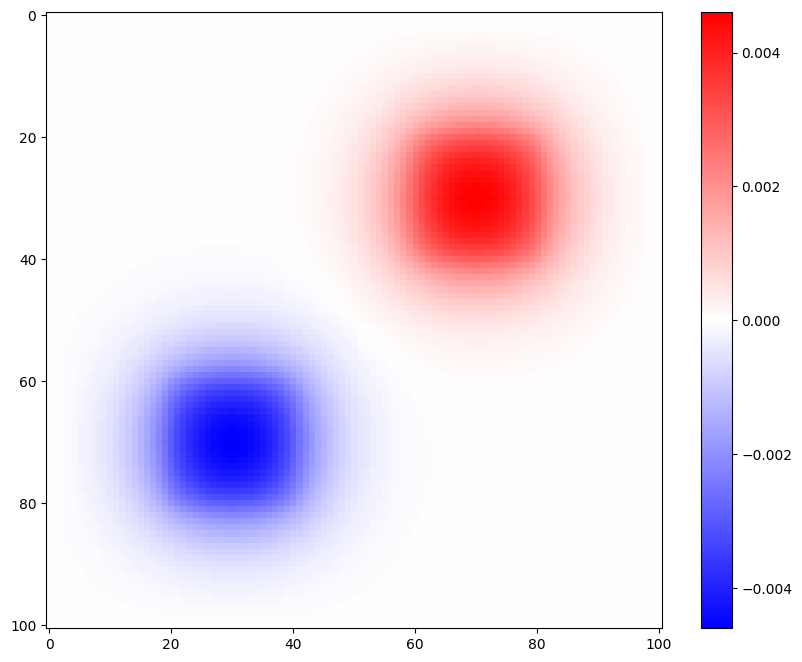

In [27]:
import pylab as plt
plt.rcParams['figure.figsize'] = 10, 8
plt.imshow(phi, cmap="bwr")
#plt.clim(-2,2)
plt.colorbar()
plt.show()

Let's try it again with different charges:

In [28]:
import numpy as np

# constants
L = 1.0 # length of box
M = 100 # grid squares
a = L/M # size of a grid square

rho0 = 1.0 # Charge density
epsilon = 1.0 # Electrical permitivity
target = 1e-5   # Target accuracy

# Create arrays to hold potential values
phi      = np.zeros([M+1,M+1],float)
phiprime = np.zeros([M+1,M+1],float)
rho      = np.zeros([M+1,M+1],float)
rho[20:41,20:41] = -rho0
rho[20:41,60:81] = -rho0
rho[45:55,45:55] = 2*rho0
rho[60:81,20:81] = -rho0

# Main loop
delta = 1.0

while delta>target:

    # Fix boundaries at 0V
    phiprime[0,:] = 0.0
    phiprime[M,:] = 0.0
    phiprime[:,0] = 0.0
    phiprime[:,M] = 0.0

    # Interior values
    phiprime[1:M,1:M] = (phi[0:M-1,1:M] + phi[2:M+1,1:M] \
                       + phi[1:M,0:M-1] + phi[1:M,2:M+1])/4 \
                       + rho[1:M,1:M]*a*a/(4*epsilon)

    # Calculate maximum difference from old values
    delta = np.max(abs(phi-phiprime))

    # Swap the two arrays around
    phi,phiprime = phiprime,phi

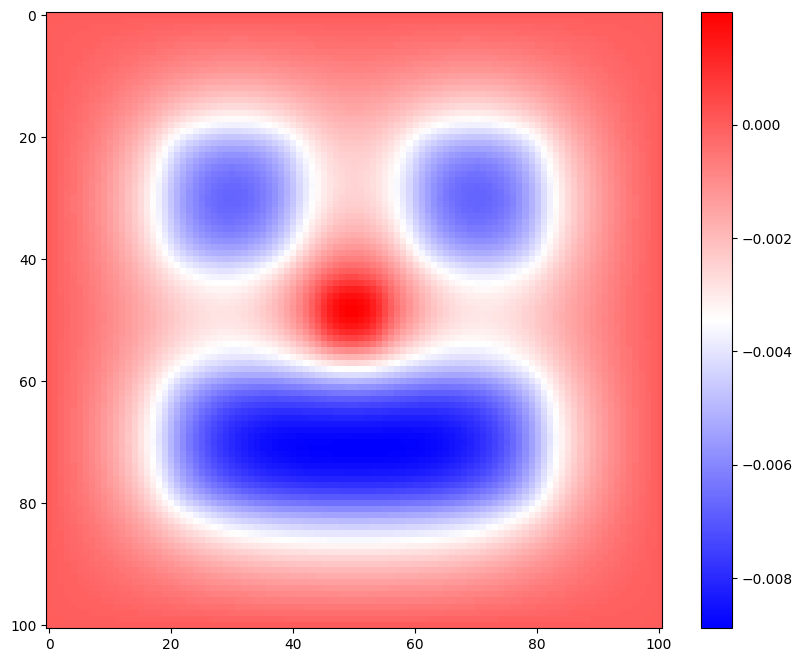

In [29]:
import pylab as plt
plt.rcParams['figure.figsize'] = 10, 8
plt.imshow(phi, cmap="bwr")
#plt.clim(-0.001,0.001)
plt.colorbar()
plt.show()

# Overrelaxation & the Gauss Seidel method

As we discussed above, the Jacobi method for solving boundary value problems is somewhat slow for a large grid. We can speed up the method usting two techniques:

#### Overrelaxation

Recall: The Jacobi method makes use of the relaxation method. We take an initial guess, plug that guess into the equation, and then use the result of that equation as our guess for the next iteration. The overrelaxation method can speed this up by "overshooting". Everytime the method produces a new guess, we change the function by a small fraction more such that we converge faster.

#### Guass Seidel

Recall: In order to calculate a new value for the potential at a given point with the Jacobi method we used the 4 neighboring points as well as the previous value of the potential at that point. If we're iterating through the grid, instead of using the 4 "old" values for the neighboring points, we incorporate any new values for the neighboring points that we have already calculated which will make our new value for the current point more accurate.


In [30]:
### Old way (Jacobi method from above)
from numpy import empty,zeros,max
import time
start = time.time()

# Constants
M = 10         # Grid squares on a side
V = 1.0         # Voltage at top wall
target = 1e-4   #1e-6   # Target accuracy

# Create arrays to hold potential values

# Array containing the potential values for this iteration which are used to calculate the
#   values for the next iteration
phi = zeros([M+1,M+1],float)

# Array containing the newly calculated potential values at each grid point
phiprime = empty([M+1,M+1],float)

# Set Boundary contitions
phi[0,:] = V

print(phi.shape)
print(phiprime.shape)

# Main loop
delta = 1.0
while delta>target:

    phiprime[:,:] = phi[:,:]  # Copy all values from phi to phiprime

    # Calculate new values of the potential
    for i in range(M+1):
        for j in range(M+1):
            if i==0 or i==M or j==0 or j==M:
                phiprime[i,j] = phi[i,j]
            else:
                phiprime[i,j] = (phi[i+1,j] + phi[i-1,j] \
                                 + phi[i,j+1] + phi[i,j-1])/4

    # Calculate maximum difference from old values
    delta = max(abs(phi-phiprime))

    # Swap the two arrays around
    phi,phiprime = phiprime,phi

end = time.time()
print("Time Elapsed: ",end - start)

(11, 11)
(11, 11)
Time Elapsed:  0.021068096160888672


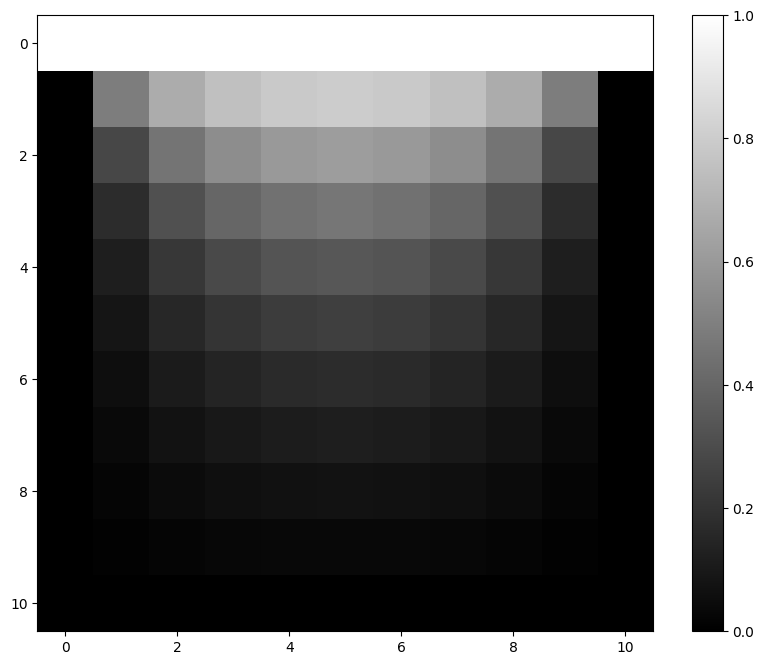

In [31]:
import pylab as plt
plt.rcParams['figure.figsize'] = 10, 8
plt.imshow(phi,origin='upper')
plt.colorbar()
plt.show()

In [32]:
### Gauss Seidel with Overrelaxation
from numpy import empty,zeros,max
import time
start = time.time()

# Constants
L = 1.0
M = 10         # Grid squares on a side
V = 1.0         # Voltage at top wall
target = 1e-4   #1e-6   # Target accuracy
omega = 0.1

# Create arrays to hold potential values

# This time only one array is necessary
phiGS = zeros([M+1,M+1],float)
# Set boundary conditions:
phiGS[0,:] = V

# We will create another array to check convergence.
#  Stop iterating when the difference between two iterations is smaller than some target
dphi = zeros([M+1,M+1],float)

print(phiGS.shape)

plt.rcParams['figure.figsize'] = 10, 8

# Main loop
delta = 1.0
while delta>target:

    # Calculate new values of the potential
    for i in range(0,M+1):
        for j in range(0,M+1):

            if i==0 or i==M or j==0 or j==M:
                phiGS[i,j] = phiGS[i,j]
            else:
                # Perform Gauss-Seidel with Overrelaxation
                phiGS[i,j] += (1+omega)*( (phiGS[i+1,j] + phiGS[i-1,j] + phiGS[i,j+1] + phiGS[i,j-1])/4 - phiGS[i,j])
                print(phiGS)

                # Check change for target
                dphi[i,j]=(1+omega)*( (phiGS[i+1,j] + phiGS[i-1,j] + phiGS[i,j+1] + phiGS[i,j-1])/4 - phiGS[i,j])

    # Calculate maximum difference from old values
    delta = max(abs(dphi))
    print("delta =", delta)
    #plt.imshow(phiGS)
    #plt.show()

end = time.time()
print("Time Elapsed: ",end - start)

Streaming output truncated to the last 5000 lines.
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]]
[[1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.        ]
 [0.         0.48752458 0.67228804 0.75112451 0.78536743 0.79528889
  0.7857862  0.7518385  0.67306896 0.48807477 0.        ]
 [0.         0.27841026 0.45140967 0.54793317 0.59620511 0.61109225
  0.5969518  0.54920619 0.45280193 0.27918889 0.        ]
 [0.         0.17518125 0.30756082 0.39356404 0.44095869 0.45636855
  0.44204956 0.39542383 0.30959477 0.17661407 0.        ]
 [0.         0.11631418 0.21244764 0.2806434  0.32069018 0.33421581
  0.3218908  0.28269019 0.21468589 0.11789071 0.        ]
 [0.         0.07891317 0.1470992  0.19800343 0.22914019 0.23995891
  0.23032249 0.20001889 0.149303   0.08046524 0.        ]
 [0.         0.05345354 0.10074131 0.13711416 0.15994469 0.16804584
  0.16099845 0

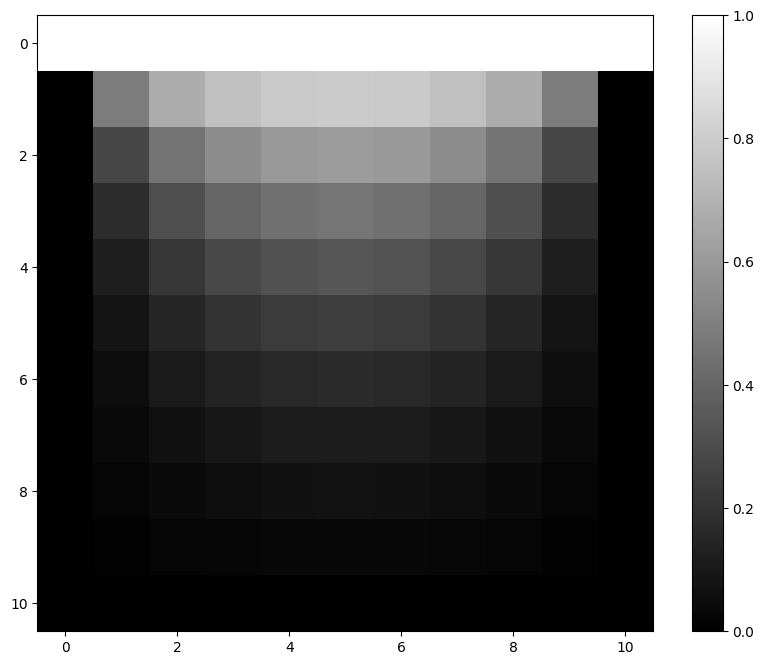

In [33]:
import pylab as plt
plt.rcParams['figure.figsize'] = 10, 8
plt.imshow(phiGS)#,origin='lower')
plt.colorbar()
#gray()
plt.show()

In [34]:
### Gauss Seidel with Overrelaxation
# Can we check which value of omega converges fastest? Yes, by trying multiple values of omega!

from numpy import empty,zeros,max
import time


# Constants
L = 1.0
M = 60         # Grid squares on a side
V = 1.0         # Voltage at top wall
target = 1e-4   #1e-6   # Target accuracy
#omega = 0.9



omegas = [0.0000000001, 0.000001, 0.0001, 0.001, 0.1, 0.5,2]#,0.91,0.9999]
times = []

for k in range(len(omegas)):


    # Create arrays to hold potential values
    phiGS = zeros([M+1,M+1],float)
    phiGS[0,:] = V
    dphi = zeros([M+1,M+1],float)

    print(phiGS.shape)
    print(dphi.shape)

    # Main loop
    delta = 1.0

    start = time.time()
    while delta>target:

        # Calculate new values of the potential
        for i in range(1,M):
            for j in range(1,M):
                # Perform Gauss-Seidel with Overrelaxation
                dphi[i,j] = (1+omegas[k])*( (phiGS[i+1,j] + phiGS[i-1,j] + phiGS[i,j+1] + phiGS[i,j-1])/4 - phiGS[i,j])
                phiGS[i,j] += dphi[i,j]

        # Calculate maximum difference from old values
        delta = max(abs(dphi))

    end = time.time()
    print("Omega = ",omegas[k],"Time Elapsed: ",end - start)
    elapsed = end - start
    times.append(elapsed)

(61, 61)
(61, 61)
Omega =  1e-10 Time Elapsed:  7.109423875808716
(61, 61)
(61, 61)
Omega =  1e-06 Time Elapsed:  10.658397674560547
(61, 61)
(61, 61)
Omega =  0.0001 Time Elapsed:  8.109890699386597
(61, 61)
(61, 61)
Omega =  0.001 Time Elapsed:  6.907397508621216
(61, 61)
(61, 61)
Omega =  0.1 Time Elapsed:  11.325816869735718
(61, 61)
(61, 61)
Omega =  0.5 Time Elapsed:  3.3669865131378174
(61, 61)
(61, 61)
Omega =  2 Time Elapsed:  8.028536558151245


/tmp/ipython-input-4131925097.py:41: RuntimeWarning: overflow encountered in scalar add
  dphi[i,j] = (1+omegas[k])*( (phiGS[i+1,j] + phiGS[i-1,j] + phiGS[i,j+1] + phiGS[i,j-1])/4 - phiGS[i,j])
/tmp/ipython-input-4131925097.py:41: RuntimeWarning: invalid value encountered in scalar subtract
  dphi[i,j] = (1+omegas[k])*( (phiGS[i+1,j] + phiGS[i-1,j] + phiGS[i,j+1] + phiGS[i,j-1])/4 - phiGS[i,j])


In [35]:
import matplotlib.pyplot as plt

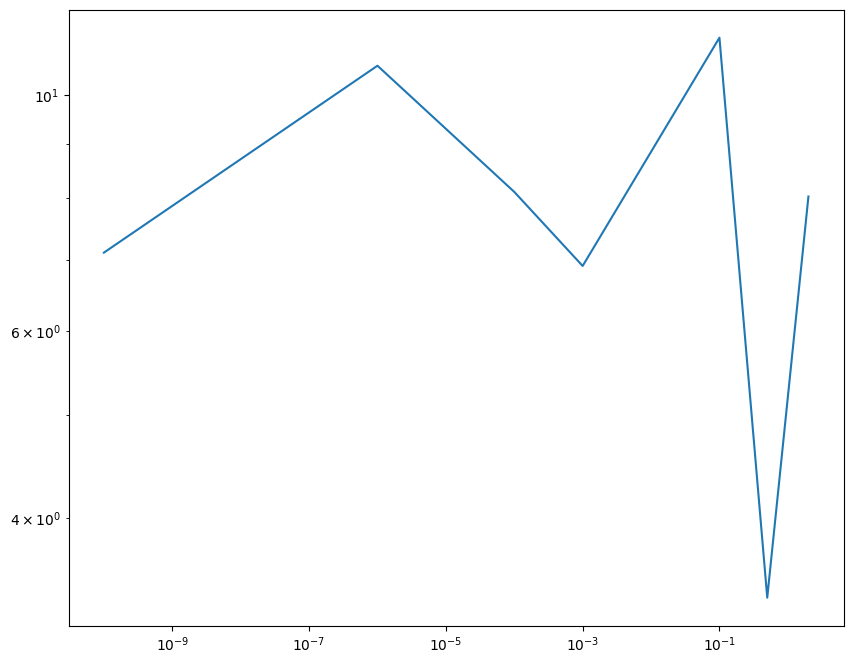

In [36]:
plt.plot(omegas[0:],times[0:])
plt.yscale('log')
plt.xscale('log')
plt.show()

# Initial value problems

## Heat transfer

The heat equation (or diffusion equation) in one dimension includes both time and space:

$\frac{\partial T}{\partial t}=D\frac{\partial^2 T}{\partial x^2}$

Since time is now involved this becomes a "initial value problem". We still have boundary conditions in the spatial dimension, but we only know the initial value in the time dimension.

## FTCS scheme (Forward-Time Central-Space)

Let's again divide the spatial dimension into a grid of points with spacing $a$ (since we are in 1D this is just a line with evenly spaced points). We can then write the derivative using the method of finite differences:

$\frac{\partial^2 T}{\partial x^2}=\frac{T(x+a,t)+T(x-a,t)-2T(x,t)}{a^2}$

so our equation becomes:

$\frac{d T}{d t}=\frac{D}{a^2}[T(x+a,t)+T|(x-a,t)-2T(x,t)]$

We now have a set of simultaneous ordinary differential equations like the ones we discussed earlier. Once again we can use Euler's method to solve this:

$\frac{d T}{d t}=f(T,t)$

$T(t+\Delta t)=T(t)+\Delta t\frac{d T}{dt} =T(t)+\Delta t f(T,t) $

So therefore our differential equation becomes:

$T(x,t+\Delta t)=T(x,t)+\Delta t\frac{D}{a^2}[T(x+a,t)+T(x-a,t)-2T(x,t)]$

If we know the value of T at every grid point at some time $t$, then this equation tells the value of T at each grid point at time $t+\Delta t$ . One way to think about this:

  * $[T(x+a,t)+T(x-a,t)-2T(x,t)]$ is our discrete second derivative (finite differences). It tells us something about curvature.
  * For a given grid point, if the neighbors are hotter than the point, this term is positive (concave up), and the point heats up for the next time iteration
  * If the neighbors are cooler, this term is negative (concave down), and the point cools down for the next time iteration.

#### Example: Stainless steel container

Imagine a 1cm thick stainless steel container which is initially at T = 20 C. If we fill the container with hot water (50 C) and emerse it a bath of cold water (0 C), find the temperature profile of the steel as a function of time and as a function of the distance x from the hot side to the cold side. The thermal diffusivity of stainless steel is $D = 4.25 \times 10^{-5}$ m$^2$ s$^{-1}$.


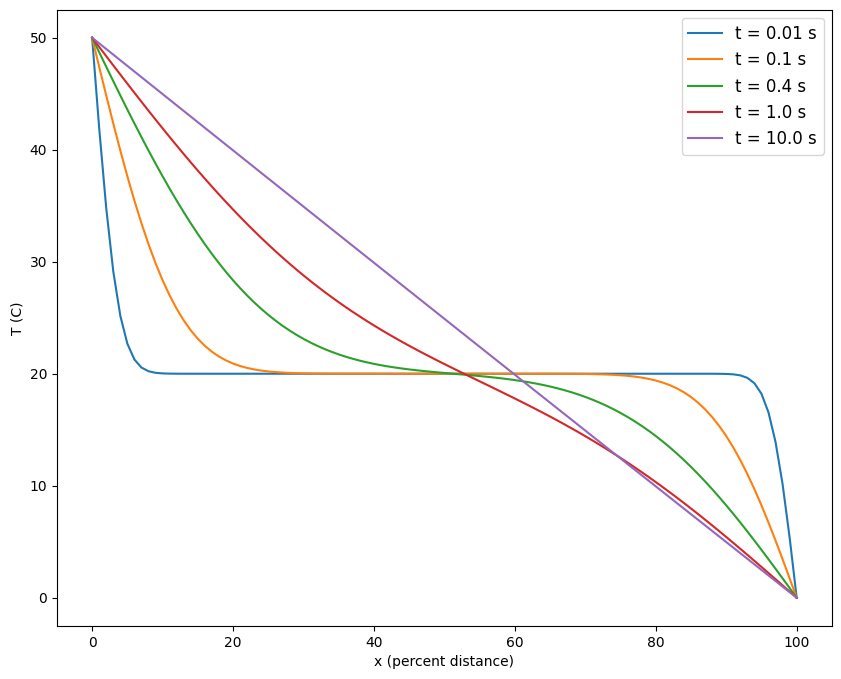

In [42]:
from numpy import empty

# Constants
L = 0.01      # Thickness of steel in meters
D = 4.25e-6   # Thermal diffusivity
N = 100       # Number of divisions in grid
a = L/N       # Grid spacing
h = 1e-4      # Time-step
epsilon = h/1000

Tlo = 0.0     # Low temperature in Celcius
Tmid = 20.0   # Intermediate temperature in Celcius
Thi = 50.0    # Hi temperature in Celcius

t1 = 0.01
t2 = 0.1
t3 = 0.4
t4 = 1.0
t5 = 10.0
tend = t5 + epsilon

# Create arrays
T = empty(N+1,float) # Temperature Array - Tracks temperature at each grid point at the "current time"
T[0] = Thi
T[N] = Tlo
T[1:N] = Tmid
Tp = empty(N+1,float) # Temperature "Prime" Array - Tracks temperature at each grid point at the next time t + dt
Tp[0] = Thi
Tp[N] = Tlo

# Main loop
t = 0.0
c = h*D/(a*a) # scaling factor from our derivation above.
while t<tend:

    # Calculate the new values of T
    for i in range(1,N):
        Tp[i] = T[i] + c*(T[i+1]+T[i-1]-2*T[i]) # Future = present + change, where the change is based on neighbors
    T,Tp = Tp,T # Swap times (T for the next itration will be the Tprime from this iteration)
    t += h

    # Make plots at the given times
    if abs(t-t1)<epsilon:
        plt.plot(T,label="t = 0.01 s")
    if abs(t-t2)<epsilon:
        plt.plot(T,label="t = 0.1 s")
    if abs(t-t3)<epsilon:
        plt.plot(T,label="t = 0.4 s")
    if abs(t-t4)<epsilon:
        plt.plot(T,label="t = 1.0 s")
    if abs(t-t5)<epsilon:
        plt.plot(T,label="t = 10.0 s")

plt.legend(loc='upper right', fontsize='large')
plt.xlabel("x (percent distance)")
plt.ylabel("T (C)")
plt.show()


Turn this into an animation

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Turn off interactive plotting to get animation to work
plt.ioff()

# Constants
L = 0.01
D = 4.25e-6
N = 100
a = L/N
h = 1e-4

Tlo = 0.0
Tmid = 20.0
Thi = 50.0

# Initialization
T = np.empty(N+1, float) # Temperature Array - Tracks temperature at each grid point at the "current time"
T[0] = Thi
T[N] = Tlo
T[1:N] = Tmid

Tp = np.empty(N+1, float) # Temperature "Prime" Array - Tracks temperature at each grid point at the next time t + dt
Tp[0] = Thi
Tp[N] = Tlo

c = h*D/(a*a) # scaling factor from our derivation above.
t = 0.0

# Plotting Setup
fig, ax = plt.subplots()
x_points = np.linspace(0, 100, N+1)
line, = ax.plot(x_points, T, color='red', label='Temperature')
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

ax.set_ylim(0, 60)
ax.set_xlabel("x (percent distance)")
ax.set_ylabel("T (C)")
ax.legend(loc='upper right')
ax.grid(True)

# Animation Function (this will also do our solving)
def update(frame):
    global T, Tp, t
    steps_per_frame = 50
    for _ in range(steps_per_frame):
        for i in range(1, N):
            Tp[i] = T[i] + c*(T[i+1] + T[i-1] - 2*T[i])
        T, Tp = Tp, T
        t += h
    line.set_ydata(T)
    time_text.set_text(f'Time = {t:.3f} s')
    return line, time_text

# Run and Render
ani = FuncAnimation(fig, update, frames=350, interval=40, blit=True)
# interval = delay between frames in ms. smaller interval means video plays faster
# blit = True makes it run more smoothly by updating only the line that changes

# Render the video directly.
HTML(ani.to_html5_video())

In [44]:
# Turn interactive plotting back on
plt.ion()

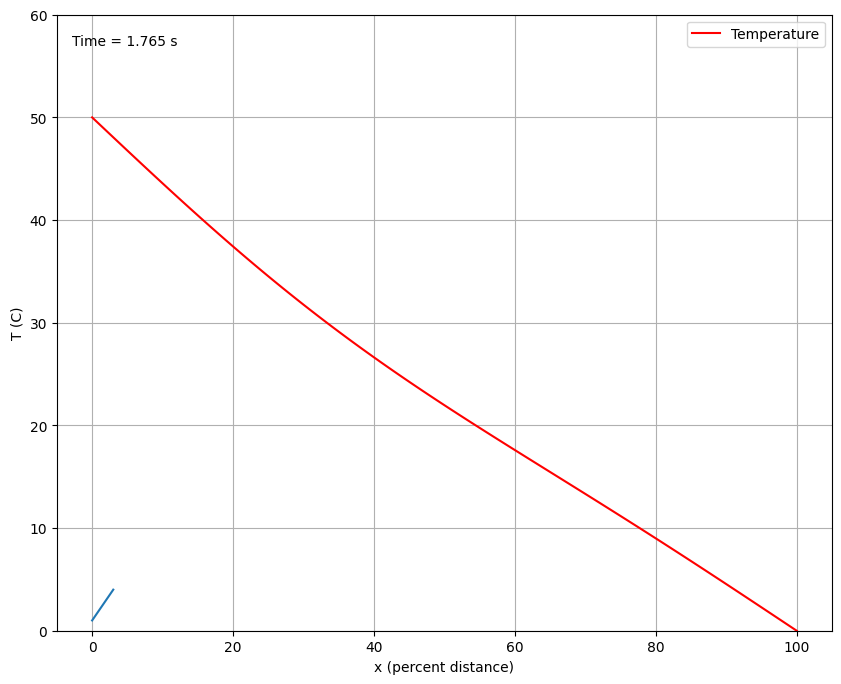

In [45]:
plt.plot([1,2,3,4])
plt.show()

## Wave Equation

Consider the wave equation:

$$
\frac{\partial^2 \psi}{\partial t^2} = v^2 \frac{\partial^2 \psi}{\partial x^2}
$$

I like to think about this equation in terms of the vertical displacement of a taught string. Here:
* $\psi(x,t)$ is the vertical displacement (height) of the string at position $x$ and time $t$.
* $v$ is the wave propagation speed (speed of sound on the string).
* $\frac{\partial^2 \psi}{\partial t^2}$ is the vertical acceleration of a string segment.
* $\frac{\partial^2 \psi}{\partial x^2}$ is the curvature(concavity) of the string.

We can see that this is a second-order partial differential equation (PDE) that relates the acceleration of the string to its curvature. The tension in a curved string creates a net restoring force. If the string is concave up the force pulls it up and if the string is concave down the force pulls it down.

Can we apply the FTCS scheme to the wave equation? We can try, but it turns out FTCS is numerically unstable for the wave equation.

### Example - Piano String hit by hammer

We will model the piano string first using FTCS, observe its unstabel behavior, and then modify the method with a leapfrog-like technique to make it stable.

#### Initial Conditions (The Hammer Strike)
Unlike a plucked guitar string (which starts with initial displacement but zero velocity), a piano string struck by a hammer starts with zero displacement but a nonzero initial velocity. Therefore at $t=0$:
1.  The string is perfectly flat ($\psi(x, 0) = 0$)
2.  The hammer imparts a specific velocity profile to the string. The hammer has some size $\sigma$ and hits at a given location $d$, so we can model the hammer strike as having a position dependent velocity profile defined by Gaussian curve centered at $x=d$ with width $\sigma$

$$
\frac{\partial \psi}{\partial t}(x, 0) = \frac{C}{L^2} x(L-x) \exp\left( \frac{-(x-d)^2}{2\sigma^2} \right)
$$

  * $C$ is the amplitude scaling factor (peak velocity).
  * $\sigma$ (sigma) is the width of the hammer. A larger $\sigma$ represents a softer mallet; a smaller $\sigma$ represents a sharp, hard strike.
  * $x(L-x)$ forces the velocity to be exactly zero at the boundaries ($x=0$ and $x=L$), ensuring the hammer doesn't break the fixed ends of the string.

#### Boundary Conditions
The string is fixed at both ends, meaning the displacement must always be zero at the walls.

$$
\psi(0, t) = 0 \quad \text{and} \quad \psi(L, t) = 0
$$

#### FTCS Method (which fails)

The wave equation looks like our heat diffusion equation, but with a second time derivatve instead of a first time derivative. We could try to model this using a FTCS technique, but using Euler twice to handle the second time derivative. We can define a velocity variable $u=\frac{\partial \psi}{\partial t}$ (in the code, this is `dpsi` or "psi dot") to split the problem into two coupled first-order equations:

$$
\frac{\partial \psi}{\partial t} = u \quad \text{(Velocity)}
$$

$$
\frac{\partial u}{\partial t} = v^2 \frac{\partial^2 \psi}{\partial x^2} \quad \text{(Acceleration)}
$$

Just like in the heat diffusion example we can discretize space and approximate the spatial curvature ($\frac{\partial^2 \psi}{\partial x^2}$) using the Finite Difference method. In the code, this is calculated by the function `f(psi)`:

$$
\frac{\partial^2 \psi}{\partial x^2} \approx \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{a^2}
$$

We then discretize time using a forward time method, but this time we need to do "Double Euler" (we assume we can update both position and velocity using the standard Euler method simultaneously):

$$
\psi_{\text{new}} = \psi_{\text{old}} +  \Delta t \cdot (u_{\text{old}})
$$

$$
u_{\text{new}} = u_{\text{old}} + \Delta t \cdot \left( v^2 \frac{\partial^2 \psi}{\partial x^2} \right)
$$


We will see that when we use this method (Forward Euler applied to a harmonic oscillator) it fails at larger time (it is unconditionally unstable). It does not conserve energy; instead, it adds a tiny amount of energy to the system with every time step. Over thousands of steps, this phantom energy accumulates, causing the wave amplitude to grow exponentially and explode to infinity. FTCS is not time symmetric. The future depends on the present, and approximation errors add up systematically. Remember, Euler is assuming that the next position in time depends only on the the current velocity (it assumes velocity is constant for the entire step).


#### CTCS (Leapfrog Integration)

We fix the simulation using the leapfrog method which is symmetric in time.

Again we will discretize space into $N$ steps of size $a$, and time into steps of size $w$ (or $\Delta t$). This time we will instead use a staggered grid where position exists at integer time steps ($n$). However, the leapfrog method calculates velocity at half-integer time steps ($n+1/2$)[$t=0.5, 1.5, \dots$]. However, our initial conditions give us velocity exactly at $t=0$, so we have to do one single Forward Euler step of size $\Delta t / 2$ before the main loop starts. This "kickstarts" the velocity onto the staggered grid:

Now that we know position at time =0 and thanks to the Euler kickstart we know string velocity u at time 0.5, we can use the velocity at the half-step to push the position forward:
$$
\psi^{n+1} = \psi^n + \Delta t \cdot u^{n+1/2}
$$

After we have the new position we then calculate the acceleration (curvature) based on the new position, and use it to push the velocity forward:
$$
u^{n+3/2} = u^{n+1/2} + \Delta t \left( v^2 \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{a^2} \right)
$$

This Leapfrog approach conserves energy (it is "Symplectic"), preventing the simulation from becoming numerically unstable over long durations.


In [46]:
# Waves on a string
#   solving the wave equation
#   using the FTCS scheme (Forward-Time Central-Space)
from numpy import zeros, empty, linspace, exp

# constants
L = 1.0  # string length
d = 0.1  # location of hammer strike
v = 100.0 # speed
C = 1.0 # m/s
N = 100
a = L/N
sigma = 0.3

w = 1e-6
steps = 100001 # number of time steps

# FTCS scheme
def f(y):
    res = empty(N+1, float)
    res[1:N] = (y[0:N-1]+y[2:N+1]-2*y[1:N])*(v*v)/(a*a)
    res[0] = res[N] = 0.0
    return res

# initial arrays
x = linspace(0.0,L,N+1) # position on on string
psi = zeros(N+1,float)  # profile
dpsi = C*x*(L-x)*exp(-(x-d)**2/(2*sigma*sigma))/(L*L)

# save psi at speciic times
psi0 = psi
psi1a = psi
psi1b = psi
psi1c = psi
psi1d = psi
psi1e = psi
psi1f = psi
psi1g = psi
psi2 = psi
psi3 = psi
psi3a = psi
psi3b = psi
psi3c = psi
psi3d = psi
psi3e = psi
psi3f = psi
psi3g = psi
psi3h = psi
psi3i = psi
psi4 = psi
psi4a = psi
psi4b = psi
psi4c = psi
psi4d = psi
psi4e = psi
psi4f = psi
psi4g = psi
psi4h = psi
psi4i = psi
psi4j = psi
psi4k = psi
psi4l = psi
psi4m = psi
psi4n = psi
psi4o = psi
psi4p = psi
psi4q = psi
psi4r = psi
psi5 = psi
psi6 = psi

for n in range(steps):

    psi,dpsi = psi+w*dpsi, dpsi+w*f(psi)

    if n==0:
        psi1a = psi.copy()
    if n==1:
        psi1b = psi.copy()
    if n==10:
        psi1c = psi.copy()
    if n==50:
        psi1d = psi.copy()
    if n==70:
        psi1e = psi.copy()
    if n==80:
        psi1f = psi.copy()
    if n==90:
        psi1g = psi.copy()
    if n==100:
        psi2 = psi.copy()
    if n==1000:
        psi3 = psi.copy()
    if n==2000:
        psi3a = psi.copy()
    if n==3000:
        psi3b = psi.copy()
    if n==4000:
        psi3c = psi.copy()
    if n==5000:
        psi3d = psi.copy()
    if n==6000:
        psi3e = psi.copy()
    if n==7000:
        psi3f = psi.copy()
    if n==8000:
        psi3g = psi.copy()
    if n==9000:
        psi3h = psi.copy()
    if n==9500:
        psi3i = psi.copy()
    if n==10000:
        psi4 = psi.copy()
    if n==11000:
        psi4a = psi.copy()
    if n==12000:
        psi4b = psi.copy()
    if n==13000:
        psi4c = psi.copy()
    if n==15000:
        psi4d = psi.copy()
    if n==17000:
        psi4e = psi.copy()
    if n==18000:
        psi4f = psi.copy()
    if n==19000:
        psi4g = psi.copy()
    if n==20000:
        psi4h = psi.copy()
    if n==30000:
        psi4i = psi.copy()
    if n==40000:
        psi4j = psi.copy()
    if n==50000:
        psi4k = psi.copy()
    if n==60000:
        psi4l = psi.copy()
    if n==70000:
        psi4m = psi.copy()
    if n==80000:
        psi4n = psi.copy()
    if n==90000:
        psi4o = psi.copy()
    if n==92000:
        psi4p = psi.copy()
    if n==95000:
        psi4q = psi.copy()
    if n==98000:
        psi4r = psi.copy()
    if n==100000:
        psi5 = psi.copy()
    if n==1000000:
        psi6 = psi.copy()

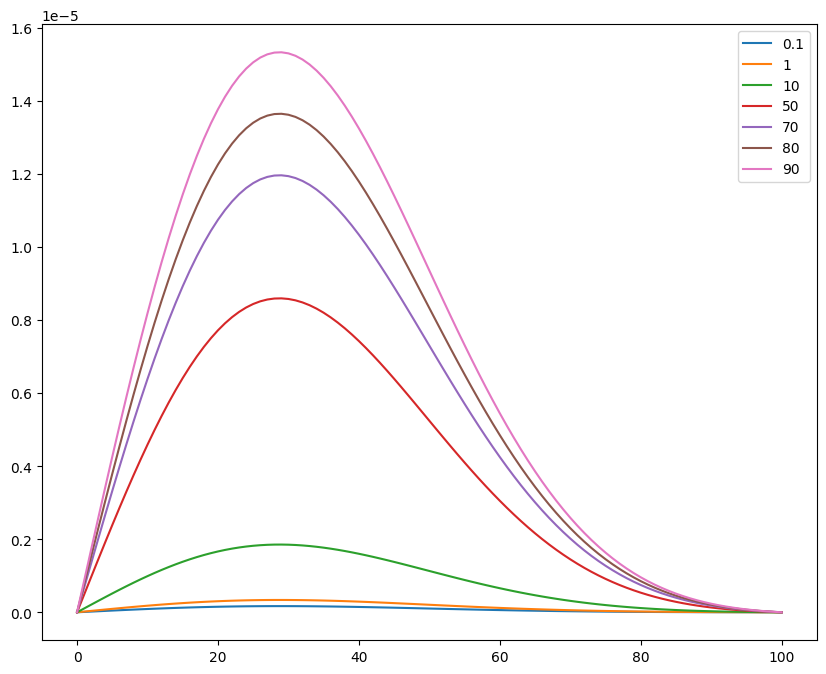

In [47]:

plt.plot(psi1a, label='0.1')
plt.plot(psi1b, label='1')
plt.plot(psi1c, label='10')
plt.plot(psi1d, label='50')
plt.plot(psi1e, label='70')
plt.plot(psi1f, label='80')
plt.plot(psi1g, label='90')
plt.legend()
plt.show()

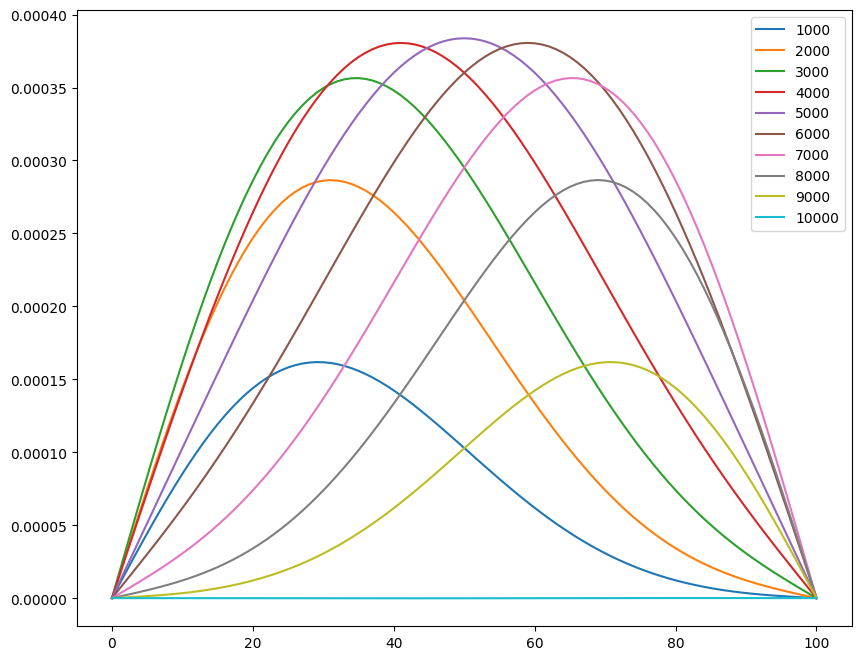

In [48]:
plt.plot(psi3 , label='1000')
plt.plot(psi3a, label='2000')
plt.plot(psi3b, label='3000')
plt.plot(psi3c, label='4000')
plt.plot(psi3d, label='5000')
plt.plot(psi3e, label='6000')
plt.plot(psi3f, label='7000')
plt.plot(psi3g, label='8000')
plt.plot(psi3h, label='9000')
plt.plot(psi4, label='10000')
plt.legend()
plt.show()

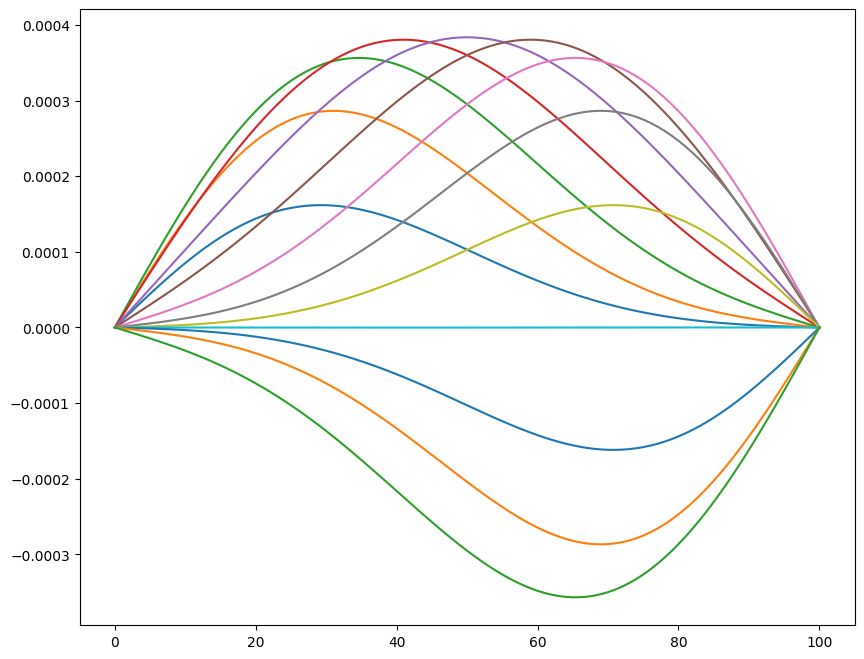

In [49]:
plt.plot(psi3, label='1000')
plt.plot(psi3a, label='2000')
plt.plot(psi3b, label='3000')
plt.plot(psi3c, label='4000')
plt.plot(psi3d, label='5000')
plt.plot(psi3e, label='6000')
plt.plot(psi3f, label='7000')
plt.plot(psi3g, label='8000')
plt.plot(psi3h, label='9000')
plt.plot(psi4, label='10000')
plt.plot(psi4a, label='11000')
plt.plot(psi4b, label='12000')
plt.plot(psi4c, label='13000')
#plt.legend()
plt.show()

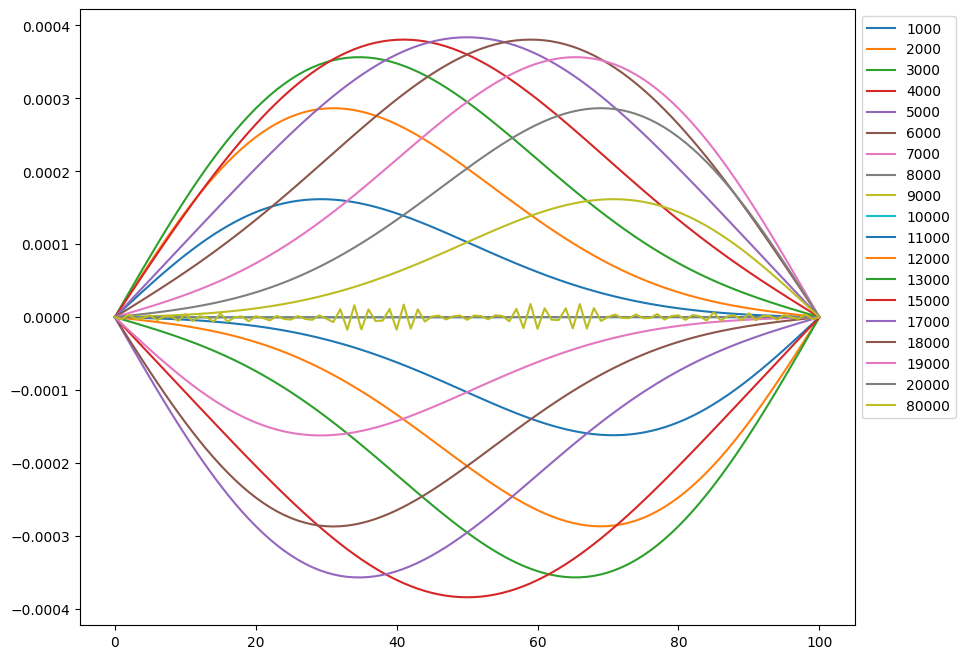

In [50]:
plt.plot(psi3, label='1000')
plt.plot(psi3a, label='2000')
plt.plot(psi3b, label='3000')
plt.plot(psi3c, label='4000')
plt.plot(psi3d, label='5000')
plt.plot(psi3e, label='6000')
plt.plot(psi3f, label='7000')
plt.plot(psi3g, label='8000')
plt.plot(psi3h, label='9000')
plt.plot(psi4, label='10000')
plt.plot(psi4a, label='11000')
plt.plot(psi4b, label='12000')
plt.plot(psi4c, label='13000')
plt.plot(psi4d, label='15000')
plt.plot(psi4e, label='17000')
plt.plot(psi4f, label='18000')
plt.plot(psi4g, label='19000')
plt.plot(psi4h, label='20000')
#plt.plot(psi4i, label='30000')
#plt.plot(psi4j, label='40000')
#plt.plot(psi4k, label='50000')
#plt.plot(psi4l, label='60000')
#plt.plot(psi4m, label='70000')
plt.plot(psi4n, label='80000')
#plt.plot(psi5 , label='100000')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

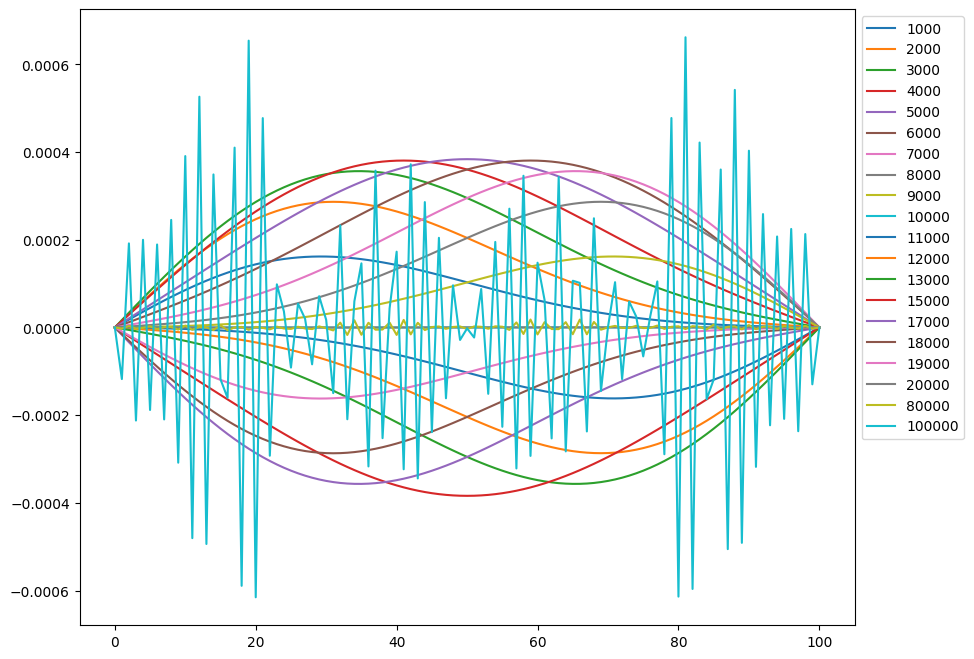

In [51]:
plt.plot(psi3, label='1000')
plt.plot(psi3a, label='2000')
plt.plot(psi3b, label='3000')
plt.plot(psi3c, label='4000')
plt.plot(psi3d, label='5000')
plt.plot(psi3e, label='6000')
plt.plot(psi3f, label='7000')
plt.plot(psi3g, label='8000')
plt.plot(psi3h, label='9000')
plt.plot(psi4, label='10000')
plt.plot(psi4a, label='11000')
plt.plot(psi4b, label='12000')
plt.plot(psi4c, label='13000')
plt.plot(psi4d, label='15000')
plt.plot(psi4e, label='17000')
plt.plot(psi4f, label='18000')
plt.plot(psi4g, label='19000')
plt.plot(psi4h, label='20000')
#plt.plot(psi4i, label='30000')
#plt.plot(psi4j, label='40000')
#plt.plot(psi4k, label='50000')
#plt.plot(psi4l, label='60000')
#plt.plot(psi4m, label='70000')
plt.plot(psi4n, label='80000')
plt.plot(psi5 , label='100000')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

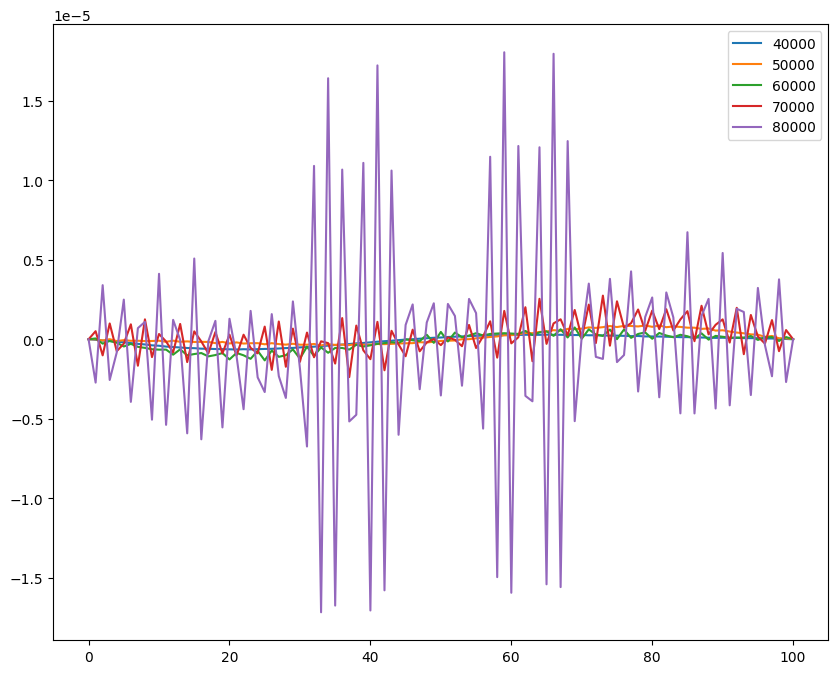

In [52]:
plt.plot(psi4j, label='40000')
plt.plot(psi4k, label='50000')
plt.plot(psi4l, label='60000')
plt.plot(psi4m, label='70000')
plt.plot(psi4n, label='80000')
plt.legend()
plt.show()

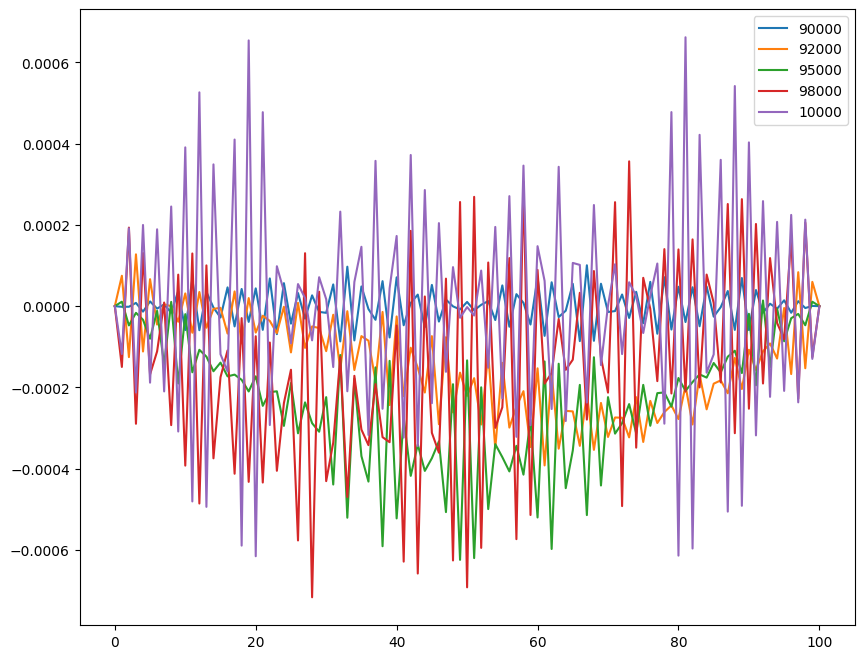

In [53]:
plt.plot(psi4o, label='90000')
plt.plot(psi4p, label='92000')
plt.plot(psi4q, label='95000')
plt.plot(psi4r, label='98000')
plt.plot(psi5, label='10000')
plt.legend()
plt.show()

We can make the wave equation solution stable if we use the leapfrog method: Central-Time Central-Space (CTCS)

In [54]:
# Waves on a string
#   solving the wave equation
#   using the CTCS scheme (Central-Time Central-Space)
from numpy import zeros, empty, linspace, exp

# constantsC
L = 1.0  # string length
d = 0.1  # location of hammer strike
v = 100.0 # speed
C = 1.0 # m/s
N = 100
a = L/N
sigma = 0.3

w = 1e-6
steps = 100001 # number of time steps

# FTCS scheme
def f(y):
    res = empty(N+1, float)
    res[1:N] = (y[0:N-1]+y[2:N+1]-2*y[1:N])*(v*v)/(a*a)
    res[0] = res[N] = 0.0
    return res

# initial arrays
x = linspace(0.0,L,N+1) # position on on string
psi = zeros(N+1,float)  # profile
dpsi = C*x*(L-x)*exp(-(x-d)**2/(2*sigma*sigma))/(L*L)

# save psi at speciic times
psi0 = psi
psi1a = psi
psi1b = psi
psi1c = psi
psi1d = psi
psi1e = psi
psi1f = psi
psi1g = psi
psi2 = psi
psi3 = psi
psi3a = psi
psi3b = psi
psi3c = psi
psi3d = psi
psi3e = psi
psi3f = psi
psi3g = psi
psi3h = psi
psi3i = psi
psi4 = psi
psi4a = psi
psi4b = psi
psi4c = psi
psi4d = psi
psi4e = psi
psi4f = psi
psi4g = psi
psi4h = psi
psi4i = psi
psi4j = psi
psi4k = psi
psi4l = psi
psi4m = psi
psi4n = psi
psi4o = psi
psi4p = psi
psi4q = psi
psi4r = psi
psi5 = psi
psi6 = psi

# Leapfrog - Kick start dpsi by half a time step
dpsi += (w/2) * f(psi)
for n in range(steps):

    #psi,dpsi = psi+w*dpsi, dpsi+w*f(psi)

    # Leapfrog instead
    psi += w * dpsi
    dpsi += w * f(psi)

    if n==0:
        psi1a = psi.copy()
    if n==1:
        psi1b = psi.copy()
    if n==10:
        psi1c = psi.copy()
    if n==50:
        psi1d = psi.copy()
    if n==70:
        psi1e = psi.copy()
    if n==80:
        psi1f = psi.copy()
    if n==90:
        psi1g = psi.copy()
    if n==100:
        psi2 = psi.copy()
    if n==1000:
        psi3 = psi.copy()
    if n==2000:
        psi3a = psi.copy()
    if n==3000:
        psi3b = psi.copy()
    if n==4000:
        psi3c = psi.copy()
    if n==5000:
        psi3d = psi.copy()
    if n==6000:
        psi3e = psi.copy()
    if n==7000:
        psi3f = psi.copy()
    if n==8000:
        psi3g = psi.copy()
    if n==9000:
        psi3h = psi.copy()
    if n==9500:
        psi3i = psi.copy()
    if n==10000:
        psi4 = psi.copy()
    if n==11000:
        psi4a = psi.copy()
    if n==12000:
        psi4b = psi.copy()
    if n==13000:
        psi4c = psi.copy()
    if n==15000:
        psi4d = psi.copy()
    if n==17000:
        psi4e = psi.copy()
    if n==18000:
        psi4f = psi.copy()
    if n==19000:
        psi4g = psi.copy()
    if n==20000:
        psi4h = psi.copy()
    if n==30000:
        psi4i = psi.copy()
    if n==40000:
        psi4j = psi.copy()
    if n==50000:
        psi4k = psi.copy()
    if n==60000:
        psi4l = psi.copy()
    if n==70000:
        psi4m = psi.copy()
    if n==80000:
        psi4n = psi.copy()
    if n==90000:
        psi4o = psi.copy()
    if n==92000:
        psi4p = psi.copy()
    if n==95000:
        psi4q = psi.copy()
    if n==98000:
        psi4r = psi.copy()
    if n==100000:
        psi5 = psi.copy()
    if n==1000000:
        psi6 = psi.copy()

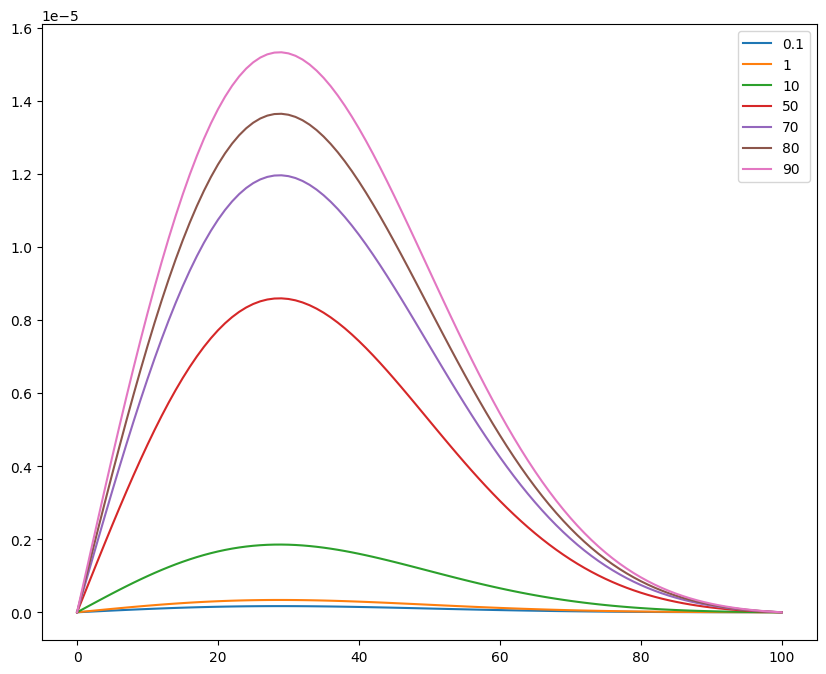

In [55]:

plt.plot(psi1a, label='0.1')
plt.plot(psi1b, label='1')
plt.plot(psi1c, label='10')
plt.plot(psi1d, label='50')
plt.plot(psi1e, label='70')
plt.plot(psi1f, label='80')
plt.plot(psi1g, label='90')
plt.legend()
plt.show()

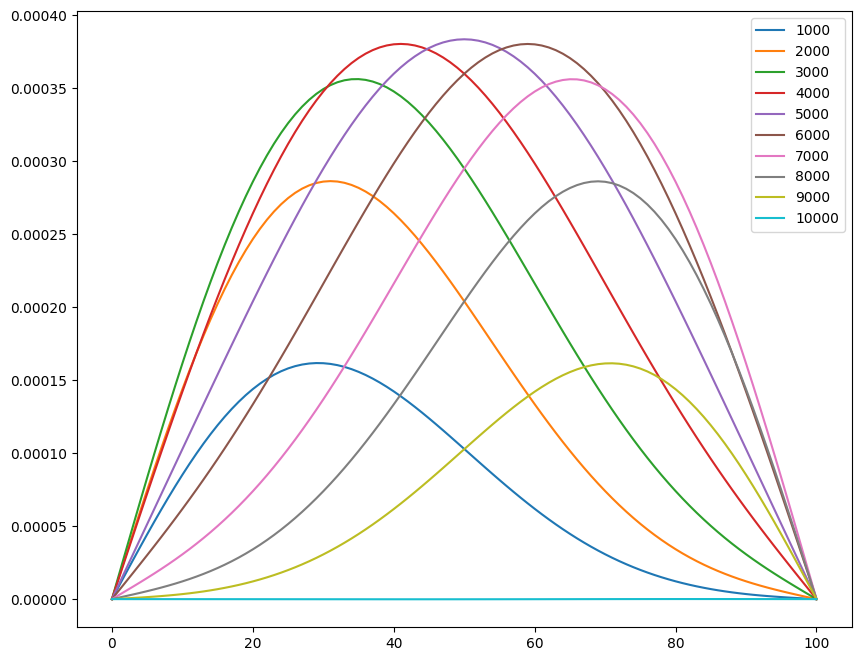

In [56]:
plt.plot(psi3 , label='1000')
plt.plot(psi3a, label='2000')
plt.plot(psi3b, label='3000')
plt.plot(psi3c, label='4000')
plt.plot(psi3d, label='5000')
plt.plot(psi3e, label='6000')
plt.plot(psi3f, label='7000')
plt.plot(psi3g, label='8000')
plt.plot(psi3h, label='9000')
plt.plot(psi4, label='10000')
plt.legend()
plt.show()

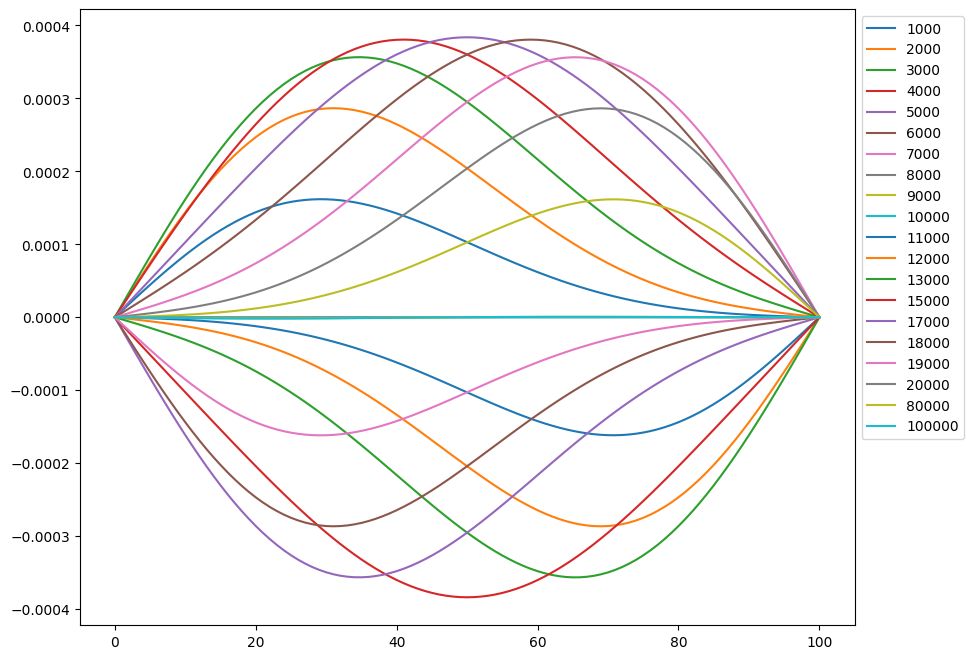

In [57]:

plt.plot(psi3, label='1000')
plt.plot(psi3a, label='2000')
plt.plot(psi3b, label='3000')
plt.plot(psi3c, label='4000')
plt.plot(psi3d, label='5000')
plt.plot(psi3e, label='6000')
plt.plot(psi3f, label='7000')
plt.plot(psi3g, label='8000')
plt.plot(psi3h, label='9000')
plt.plot(psi4, label='10000')
plt.plot(psi4a, label='11000')
plt.plot(psi4b, label='12000')
plt.plot(psi4c, label='13000')
plt.plot(psi4d, label='15000')
plt.plot(psi4e, label='17000')
plt.plot(psi4f, label='18000')
plt.plot(psi4g, label='19000')
plt.plot(psi4h, label='20000')
#plt.plot(psi4i, label='30000')
#plt.plot(psi4j, label='40000')
#plt.plot(psi4k, label='50000')
#plt.plot(psi4l, label='60000')
#plt.plot(psi4m, label='70000')
plt.plot(psi4n, label='80000')
plt.plot(psi5 , label='100000')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

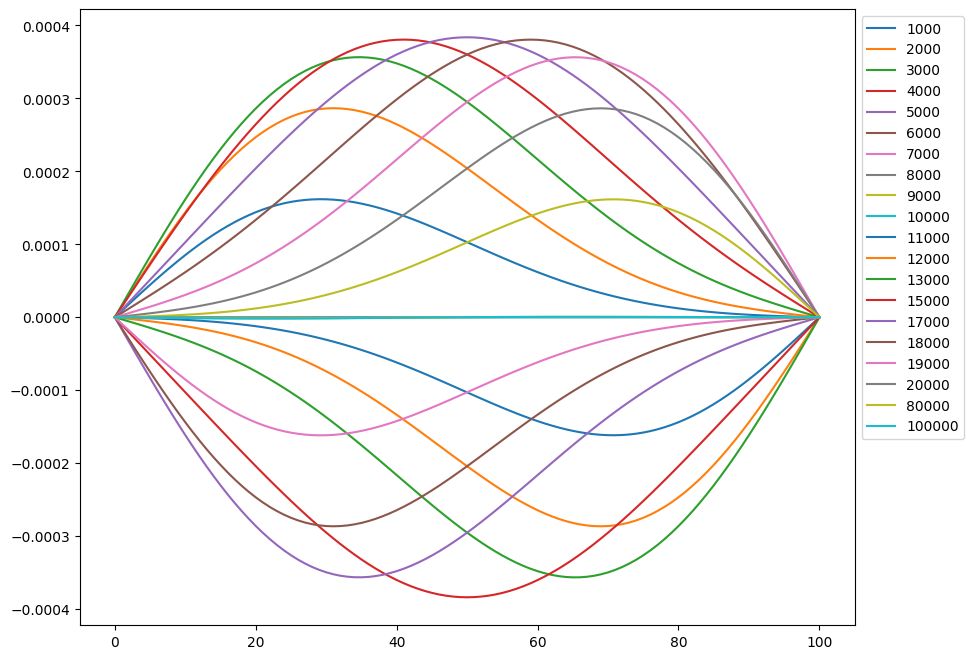

In [58]:
plt.plot(psi3, label='1000')
plt.plot(psi3a, label='2000')
plt.plot(psi3b, label='3000')
plt.plot(psi3c, label='4000')
plt.plot(psi3d, label='5000')
plt.plot(psi3e, label='6000')
plt.plot(psi3f, label='7000')
plt.plot(psi3g, label='8000')
plt.plot(psi3h, label='9000')
plt.plot(psi4, label='10000')
plt.plot(psi4a, label='11000')
plt.plot(psi4b, label='12000')
plt.plot(psi4c, label='13000')
plt.plot(psi4d, label='15000')
plt.plot(psi4e, label='17000')
plt.plot(psi4f, label='18000')
plt.plot(psi4g, label='19000')
plt.plot(psi4h, label='20000')
#plt.plot(psi4i, label='30000')
#plt.plot(psi4j, label='40000')
#plt.plot(psi4k, label='50000')
#plt.plot(psi4l, label='60000')
#plt.plot(psi4m, label='70000')
plt.plot(psi4n, label='80000')
plt.plot(psi5 , label='100000')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

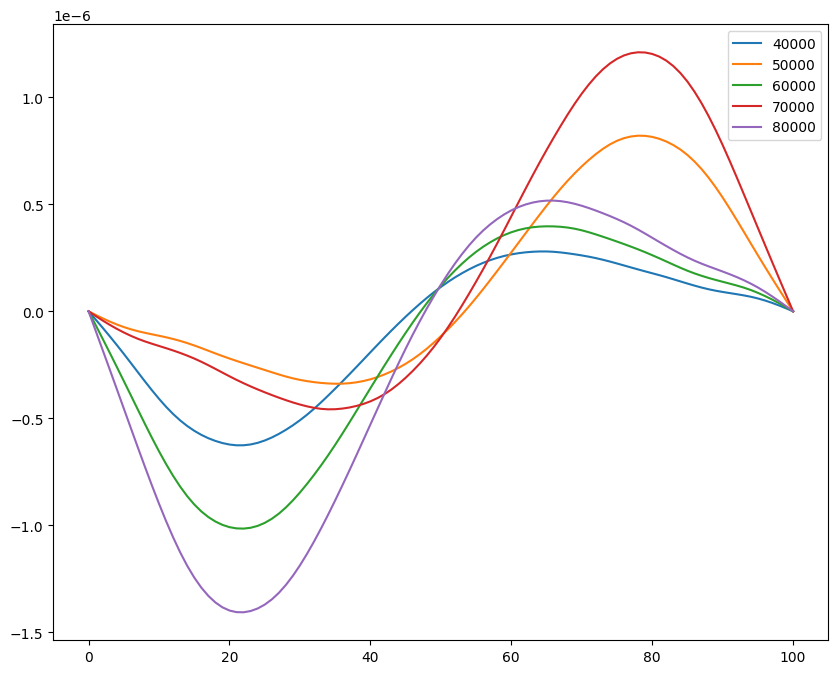

In [59]:
plt.plot(psi4j, label='40000')
plt.plot(psi4k, label='50000')
plt.plot(psi4l, label='60000')
plt.plot(psi4m, label='70000')
plt.plot(psi4n, label='80000')
plt.legend()
plt.show()

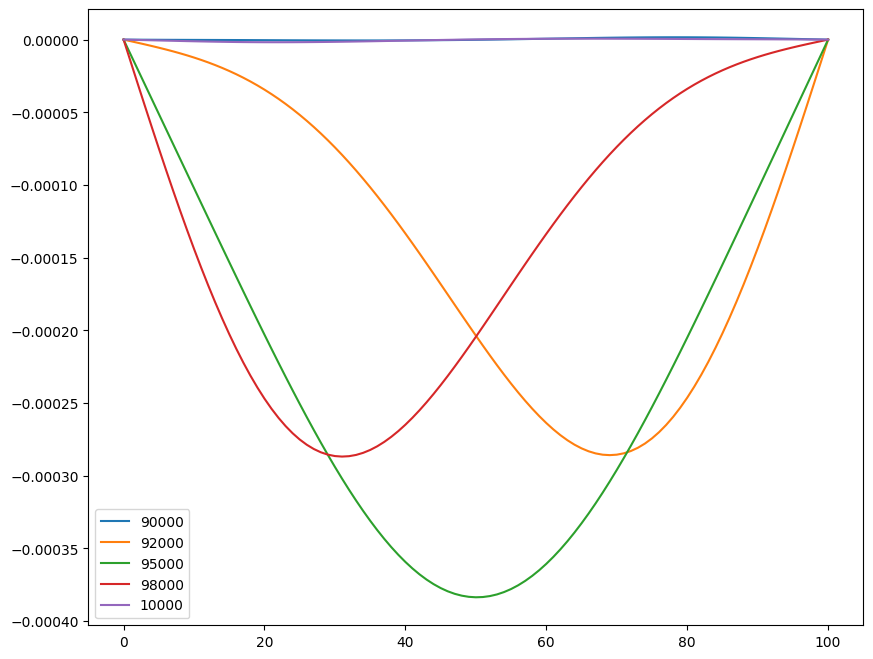

In [60]:
plt.plot(psi4o, label='90000')
plt.plot(psi4p, label='92000')
plt.plot(psi4q, label='95000')
plt.plot(psi4r, label='98000')
plt.plot(psi5, label='10000')
plt.legend()
plt.show()

# Alternative PDE Methods

### Finite Difference Methods
All of the methods we have discussed rely on numerically estimating derivatives ("central difference", "forward difference", "2nd order central difference"), applying boundary conditions and initial conditions, and dividing the object into rectangular grid points. These methods are collectivelly known as Finite Difference Methods

While the **Finite Difference Method (FDM)** is great for simple grids (like squares), real-world engineering often requires more powerful tools.

### Finite Element Method (FEM)

Instead of solving for the exact value at a grid point, FEM breaks the object into small pieces (elements) and minimizes the total error (energy) over the area of each piece. While the Finite Difference demands that the differential equation is satisfied exactly at specific, tiny grid points, the Finite Element Method admits that the solution won't be perfect everywhere but ensures the average error in an element is zero. This allows FEM to "smooth over" difficult physics and handle sharp corners or complex curves where a grid-based method would fail.


https://en.wikipedia.org/wiki/File:Example_of_2D_mesh.png

https://en.wikipedia.org/wiki/File:FEM_example_of_2D_solution.png

* **Best For:** Structural mechanics (bridges, cars), complex biological shapes (hearts, brains), and heat transfer in irregular parts.
* **Why Triangles & Pyramids?**
    * You cannot fill a curve or a sharp corner with squares without leaving jagged gaps. Triangles (2D) and Tetrahedrons (pyramids in 3D) can fit into any geometry.
    * Mesh Refinement: Triangles allow you to change scale easily. You can have tiny microscopic triangles near a sharp stress point and giant triangles in the middle of the object to save computing power. You can't do this easily with a square grid.
* **Python Packages:**
    * [FEniCS](https://fenicsproject.org/) (The most powerful/popular open-source FEM tool)
      * FEniCS is the name of the project. The software libary you import is called DOLFIN or DOLFINx
    * [SfePy](https://sfepy.org/) (Simple Finite Elements in Python)
    * [Scikit-FEM](https://scikit-fem.readthedocs.io/) (Lightweight, great for learning)

* **Non-python software** (very common in industry) :
  * https://www.comsol.com/
  * https://www.comsol.com/products
  * https://www.comsol.com/blogs/finding-the-best-way-to-make-crepes-with-fluid-dynamics-research/
  * https://www.ansys.com/
  * https://www.autodesk.com/solutions/finite-element-analysis




### Spectral Methods

Instead of chopping space into grid points, Spectral methods represent the entire solution as a sum of global waves (like sines, cosines, or Chebyshev polynomials). The computer solves for the coefficients of these waves rather than the values at points.

* **Best For:** Fluid dynamics, turbulence, and astrophysics inside simple shapes (boxes, spheres, cylinders).
* **Pros:** **Exponential Accuracy.** As you add more waves, the error drops to zero incredibly fast (much faster than Finite Difference).
* **Cons:** Bad at complex shapes. If your domain isn't a box or sphere, you generally can't use this.
* **Python Packages:**
    * [Dedalus](https://dedalus-project.org/) (Modern, high-performance spectral solver)
    * [Chebpy](https://github.com/chebpy/chebpy) (Chebyshev polynomial tools)

### 3. Finite Volume Method (FVM)

FVM divides the domain into "cells" (volumes). Instead of tracking the value at a point, it tracks the amount of stuff (mass, energy, fluid) entering and leaving the cell through its walls (flux).

* **Best For:** Fluid flow (CFD), shock waves, and problems where conserving mass/energy is critical.
* **Pros:** It strictly enforces conservation laws (mass in = mass out). It handles "shocks" (like a sonic boom or dam break) without crashing, where other methods fail.
* **Cons:** Generally harder to get high-order accuracy compared to Spectral methods.
* **Python Packages:**
    * [FiPy](https://www.ctcms.nist.gov/fipy/) (Excellent for materials science and diffusion)
    * [PyClaw](https://www.clawpack.org/pyclaw/) (For shock waves and hyperbolic equations)



